## Definição e carregamento de bases de dados para Matching

Para a estimação do modelo, serão utilizadas as seguintes covariáveis:
-> Variáveis escolhidas e suas fontes:  
 * PIB per Capita (IBGE)
 * População (IBGE)
 * Participação Setorial no PIB (IBGE)
 * Educação média (RAIS)
 * Receita Corrente Municipal Bruta (IPEADATA)

 Obs: todos as base de dados são carregadas diretamente do repositório no github. No caso da RAIS, se desejar alterar os parâmetros de busca no database, o código está como comentário.


## Importação das bibliotecas utilizadas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import time
import requests
import io
from scipy.stats import zscore
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


## Carregamento de dados do IBGE via GitHub
* PIB per Capita
* População
* Participação dos setores econômicos

> **Fonte:** `pib_percapita_municipios.parquet` (GitHub Release — mvtp23/TCC).  
> As três bases originais (pib_per_capita, populacao, pib_setor) foram consolidadas
> neste único arquivo e carregadas a seguir.


In [2]:
URL_PIB = (
    "https://github.com/mvtp23/TCC/releases/download/"
    "database_ibge/pib_percapita_municipios.parquet"
)


In [3]:
# Baixar e ler o arquivo parquet diretamente do GitHub
# (o requests lida com o redirect do GitHub Releases)
_resp = requests.get(URL_PIB, headers={"User-Agent": "Mozilla/5.0"}, allow_redirects=True)
_resp.raise_for_status()
df_raw = pd.read_parquet(io.BytesIO(_resp.content))

print(f"Shape: {df_raw.shape}")
print(f"\nColunas: {df_raw.columns.tolist()}")
df_raw.head(3)


Shape: (77980, 15)

Colunas: ['cod_municipio', 'nome_municipio', 'sigla_uf', 'ano', 'pib_reais', 'populacao', 'pib_percapita_rs', 'vab_agro_reais', 'vab_ind_reais', 'vab_serv_reais', 'vab_adm_reais', 'part_agropecuaria', 'part_industria', 'part_servicos', 'part_adm_publica']


,cod_municipio,nome_municipio,sigla_uf,ano,pib_reais,populacao,pib_percapita_rs,vab_agro_reais,vab_ind_reais,vab_serv_reais,vab_adm_reais,part_agropecuaria,part_industria,part_servicos,part_adm_publica
0,1100015,Alta Floresta D'Oeste - RO,RO,2010,262077000.0,NaN,NaN,69260000.0,16119000.0,62496000.0,93245000.0,28.72,6.68,25.92,38.67
1,1100015,Alta Floresta D'Oeste - RO,RO,2011,280510000.0,24228.0,11577.926366,73328000.0,17942000.0,65486000.0,102539000.0,28.28,6.92,25.26,39.55
2,1100015,Alta Floresta D'Oeste - RO,RO,2012,329029000.0,24069.0,13670.239727,106125000.0,18906000.0,71330000.0,112789000.0,34.33,6.12,23.07,36.48


### Mapeamento de colunas

Ajuste o dicionário `MAPA_COLUNAS` caso os nomes das colunas no parquet
sejam diferentes dos nomes utilizados no restante do notebook.

| Chave (nome no .parquet) | Valor (nome interno do notebook) |
|---|---|
| `cod_municipio` | `cod_municipio` |
| `ano` | `ano` |
| `nome_municipio` | `nome_municipio` |
| `sigla_uf` | `sigla_uf` |
| `pib_per_capita` | `pib_per_capita` |
| `populacao` | `populacao` |
| `pib_total` | `pib_total` |
| `part_servicos` | `part_servicos` |
| `part_industria` | `part_industria` |
| `part_agropecuaria` | `part_agropecuaria` |
| `part_adm_publica` | `part_adm_publica` |


In [4]:
# Renomeie as chaves para os nomes reais do seu arquivo, se necessário
MAPA_COLUNAS = {
    "cod_municipio"    : "cod_municipio",
    "ano"              : "ano",
    "nome_municipio"   : "nome_municipio",
    "sigla_uf"         : "sigla_uf",
    "pib_per_capita"   : "pib_percapita_rs",
    "populacao"        : "populacao",
    "pib_total"        : "pib_REAIS",
    "part_servicos"    : "part_servicos",
    "part_industria"   : "part_industria",
    "part_agropecuaria": "part_agropecuaria",
    "part_adm_publica" : "part_adm_publica",
}

# Rename columns (usando MAPA_COLUNAS) e normalizar nomes esperados pelo notebook
df_pib = df_raw.rename(columns=MAPA_COLUNAS).copy()

# Normalizar possíveis variações de nomes para os nomes internos esperados
_normalize = {
    "pib_REAIS": "pib_total",
    "pib_reais": "pib_total",
    "pib_total": "pib_total",
    "pib_percapita_rs": "pib_per_capita",
    "pib_per_capita": "pib_per_capita",
}

df_pib = df_pib.rename(columns={k: v for k, v in _normalize.items() if k in df_pib.columns})

# Colunas finais desejadas (conformes ao restante do notebook)
colunas_desejadas = [
    "cod_municipio", "ano", "nome_municipio", "sigla_uf",
    "pib_per_capita", "populacao", "pib_total",
    "part_servicos", "part_industria", "part_agropecuaria", "part_adm_publica"
]

# Selecionar apenas colunas presentes e avisar sobre as faltantes
presentes = [c for c in colunas_desejadas if c in df_pib.columns]
faltantes = [c for c in colunas_desejadas if c not in df_pib.columns]
if faltantes:
    print("⚠️ Colunas faltantes após rename:", faltantes)

df_pib = df_pib[presentes].copy()

# Garantir tipos corretos nas chaves de join (padrão do notebook)
df_pib["cod_municipio"] = pd.to_numeric(df_pib["cod_municipio"], errors="coerce")
df_pib["ano"]           = pd.to_numeric(df_pib["ano"],           errors="coerce")
df_pib = df_pib.dropna(subset=["cod_municipio", "ano"])
df_pib["cod_municipio"] = df_pib["cod_municipio"].astype(int)
df_pib["ano"]           = df_pib["ano"].astype(int)

print(f"Shape após seleção: {df_pib.shape}")
df_pib.head(3)

Shape após seleção: (77980, 11)


,cod_municipio,ano,nome_municipio,sigla_uf,pib_per_capita,populacao,pib_total,part_servicos,part_industria,part_agropecuaria,part_adm_publica
0,1100015,2010,Alta Floresta D'Oeste - RO,RO,NaN,NaN,262077000.0,25.92,6.68,28.72,38.67
1,1100015,2011,Alta Floresta D'Oeste - RO,RO,11577.926366,24228.0,280510000.0,25.26,6.92,28.28,39.55
2,1100015,2012,Alta Floresta D'Oeste - RO,RO,13670.239727,24069.0,329029000.0,23.07,6.12,34.33,36.48


In [5]:
# --- Verificação 1: número de dígitos do código de município ---
n_digitos = df_pib["cod_municipio"].astype(str).str.len().value_counts()
print("Dígitos em cod_municipio:")
print(n_digitos)
if n_digitos.index[0] != 7:
    print("\n⚠️  ATENÇÃO: o notebook usa 7 dígitos; verifique o código de município")
else:
    print("\n✅ Formato compatível com o notebook (7 dígitos)")

# --- Verificação 2: cobertura temporal ---
anos = sorted(df_pib["ano"].unique())
print(f"\nPeríodo disponível: {anos[0]} a {anos[-1]}")
faltando = [a for a in range(2010, 2022) if a not in anos]
if faltando:
    print(f"⚠️  Anos do período de análise faltando: {faltando}")
else:
    print("✅ Cobertura temporal suficiente para o período de análise (2010-2021)")

# --- Verificação 3: duplicatas por chave ---
n_dup = df_pib.duplicated(subset=["cod_municipio", "ano"]).sum()
print(f"\n{'✅' if n_dup == 0 else '⚠️ '} Duplicatas (cod_municipio, ano): {n_dup}")

Dígitos em cod_municipio:
cod_municipio
7    77980
Name: count, dtype: int64

✅ Formato compatível com o notebook (7 dígitos)

Período disponível: 2010 a 2023
✅ Cobertura temporal suficiente para o período de análise (2010-2021)

✅ Duplicatas (cod_municipio, ano): 0


In [6]:
# Detectar se as participações estão em % (0-100) ou proporção (0-1)
cols_part = ["part_servicos", "part_industria", "part_agropecuaria", "part_adm_publica"]
if df_pib[cols_part].max().max() > 1:
    df_pib[cols_part] = df_pib[cols_part] / 100
    print("Participações convertidas de % para proporção")
else:
    print("Participações já em proporção — sem conversão")

# pib_servicos = pib_total × part_servicos
df_pib["pib_servicos"] = df_pib["pib_total"] * df_pib["part_servicos"]

# pib_servicos_per_capita = pib_servicos / populacao
df_pib["pib_servicos_per_capita"] = df_pib["pib_servicos"] / df_pib["populacao"]

Participações convertidas de % para proporção


In [7]:
df_ibge = (
    df_pib[[
        "ano", "cod_municipio", "nome_municipio", "sigla_uf",
        "pib_per_capita", "populacao", "pib_servicos", "pib_servicos_per_capita",
        "part_servicos", "part_industria", "part_agropecuaria", "part_adm_publica"
    ]]
    .copy()
    .sort_values(["cod_municipio", "ano"])
    .reset_index(drop=True)
)

print(f"df_ibge: {df_ibge.shape[0]:,} linhas, {df_ibge['cod_municipio'].nunique():,} municípios")
df_ibge

df_ibge: 77,980 linhas, 5,570 municípios


,ano,cod_municipio,nome_municipio,sigla_uf,pib_per_capita,populacao,pib_servicos,pib_servicos_per_capita,part_servicos,part_industria,part_agropecuaria,part_adm_publica
0,2010,1100015,Alta Floresta D'Oeste - RO,RO,NaN,NaN,6.793036e+07,NaN,0.2592,0.0668,0.2872,0.3867
1,2011,1100015,Alta Floresta D'Oeste - RO,RO,11577.926366,24228.0,7.085683e+07,2924.584200,0.2526,0.0692,0.2828,0.3955
2,2012,1100015,Alta Floresta D'Oeste - RO,RO,13670.239727,24069.0,7.590699e+07,3153.724305,0.2307,0.0612,0.3433,0.3648
3,2013,1100015,Alta Floresta D'Oeste - RO,RO,13266.674440,25728.0,7.679812e+07,2985.001749,0.2250,0.0627,0.3416,0.3708
4,2014,1100015,Alta Floresta D'Oeste - RO,RO,14727.857477,25652.0,9.233408e+07,3599.488367,0.2444,0.0614,0.3419,0.3523
...,...,...,...,...,...,...,...,...,...,...,...,...
77975,2019,5300108,Brasília - DF,DF,90742.750230,3015268.0,1.410752e+11,46786.962019,0.5156,0.0389,0.0041,0.4414
77976,2020,5300108,Brasília - DF,DF,87016.159932,3055149.0,1.288828e+11,42185.434335,0.4848,0.0455,0.0068,0.4629
77977,2021,5300108,Brasília - DF,DF,92732.270204,3094325.0,1.425537e+11,46069.391838,0.4968,0.0398,0.0089,0.4545
77978,2022,5300108,Brasília - DF,DF,116700.426034,2817381.0,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Logs
df_ibge['log_pib_per_capita']          = np.log(df_ibge['pib_per_capita'])
df_ibge['log_populacao']               = np.log(df_ibge['populacao'])
df_ibge['log_pib_servicos']            = np.log(df_ibge['pib_servicos'])
df_ibge['log_pib_servicos_per_capita'] = np.log(df_ibge['pib_servicos_per_capita'])

df_ibge = df_ibge.drop(columns=[
    'pib_per_capita', 'populacao', 'pib_servicos', 'pib_servicos_per_capita'
])

# Crescimento anual por município
# diff() dentro do grupo evita herdar o último valor do município anterior
df_ibge = df_ibge.sort_values(['cod_municipio', 'ano'])

df_ibge['%_pib_per_capita'] = (
    df_ibge
    .groupby('cod_municipio')['log_pib_per_capita']
    .diff()
    .pipe(lambda s: np.exp(s) - 1)
)

df_ibge['%_pib_servicos_per_capita'] = (
    df_ibge
    .groupby('cod_municipio')['log_pib_servicos_per_capita']
    .diff()
    .pipe(lambda s: np.exp(s) - 1)
)

df_ibge

c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,ano,cod_municipio,nome_municipio,sigla_uf,part_servicos,part_industria,part_agropecuaria,part_adm_publica,log_pib_per_capita,log_populacao,log_pib_servicos,log_pib_servicos_per_capita,%_pib_per_capita,%_pib_servicos_per_capita
0,2010,1100015,Alta Floresta D'Oeste - RO,RO,0.2592,0.0668,0.2872,0.3867,NaN,NaN,18.033994,NaN,NaN,NaN
1,2011,1100015,Alta Floresta D'Oeste - RO,RO,0.2526,0.0692,0.2828,0.3955,9.356856,10.095264,18.076172,7.980908,NaN,NaN
2,2012,1100015,Alta Floresta D'Oeste - RO,RO,0.2307,0.0612,0.3433,0.3648,9.522976,10.088680,18.145019,8.056339,0.180716,0.078350
3,2013,1100015,Alta Floresta D'Oeste - RO,RO,0.2250,0.0627,0.3416,0.3708,9.493010,10.155335,18.156691,8.001356,-0.029521,-0.053499
4,2014,1100015,Alta Floresta D'Oeste - RO,RO,0.2444,0.0614,0.3419,0.3523,9.597496,10.152377,18.340924,8.188547,0.110139,0.205858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77975,2019,5300108,Brasília - DF,DF,0.5156,0.0389,0.0041,0.4414,11.415784,14.919199,25.672559,10.753360,0.059319,0.085639
77976,2020,5300108,Brasília - DF,DF,0.4848,0.0455,0.0068,0.4629,11.373849,14.932339,25.582169,10.649830,-0.041068,-0.098351
77977,2021,5300108,Brasília - DF,DF,0.4968,0.0398,0.0089,0.4545,11.437472,14.945080,25.682984,10.737904,0.065690,0.092069
77978,2022,5300108,Brasília - DF,DF,NaN,NaN,NaN,NaN,11.667365,14.851318,NaN,NaN,0.258466,NaN


## Carregamento de dados via IPEA Data  


In [9]:
df_recorrm = pd.read_parquet("https://github.com/mvtp23/TCC/releases/download/database_ipead/receita_municipal_2010_2023.parquet")

In [10]:
df_recorrm.head(10)

,CODE,RAW DATE,TERCODIGO,YEAR,NIVNOME,VALUE (R$)
DATE,,,,,,
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4301073,2010,Municípios,8963643.63
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4316972,2010,Municípios,9470921.93
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,5107578,2010,Municípios,11842374.62
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4321469,2010,Municípios,8907258.61
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4302220,2010,Municípios,10880054.90
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4319364,2010,Municípios,6958895.94
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4315958,2010,Municípios,8534927.46
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4300471,2010,Municípios,8656572.40
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4314134,2010,Municípios,7866364.68


In [11]:
codigos_municipios = pd.read_excel("https://github.com/mvtp23/TCC/releases/download/database_ibge/Codigos.Municipios.IBGE.xlsx", header=1)
codigos_municipios = codigos_municipios[["Nome_Município","Código Município Completo"]]

In [12]:

mapa_municipios_nomes = (
    codigos_municipios
    .set_index("Código Município Completo")["Nome_Município"]
    .to_dict()
)

In [13]:

# ---------------------------------------------------------------
# 4. Limpeza e adição do nome do município
# ---------------------------------------------------------------

df_receita_mun = (
    df_recorrm
    .copy()
    .reset_index()
    .rename(columns={
        "TERCODIGO" : "cod_municipio",
        "YEAR"      : "ano",
        "VALUE (R$)": "receita_corrente_municipal",   # ajuste se a unidade vier diferente
    })
)



In [14]:
# Garantir tipo numérico no código para o merge
df_receita_mun["cod_municipio"] = pd.to_numeric(
    df_receita_mun["cod_municipio"], errors="coerce"
)

df_receita_mun["municipio"] = df_receita_mun["cod_municipio"].map(mapa_municipios_nomes)
df_receita_mun["log_receita_municipal"]= np.log(df_receita_mun["receita_corrente_municipal"])
df_receita_mun.drop(columns="receita_corrente_municipal", inplace = True)

# Reordenar colunas
df_receita_mun = df_receita_mun[["cod_municipio", "municipio", "ano", "log_receita_municipal"]]


c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [15]:
df_receita_mun[np.isinf(df_receita_mun["log_receita_municipal"])]

,cod_municipio,municipio,ano,log_receita_municipal
17778,2610301,Paranatama,2013,-inf
17780,2603603,Camutanga,2013,-inf
18706,3523701,Itirapuã,2013,-inf
21662,3530706,Mogi Guaçu,2014,-inf
22072,4102802,Bela Vista do Paraíso,2014,-inf
22799,1600212,Cutias,2014,-inf
23082,3137908,Lamim,2014,-inf
23266,3301702,Duque de Caxias,2014,-inf
24605,4312427,Mormaço,2014,-inf
24606,4322152,Tunas,2014,-inf


In [16]:
mun_invalidos = df_receita_mun.loc[
    ~np.isfinite(df_receita_mun["log_receita_municipal"]),
    "cod_municipio"
].unique()

df_receita_mun = df_receita_mun[
    ~df_receita_mun["cod_municipio"].isin(mun_invalidos)
]

## Carregamento de dados RAIS

* Escolaridade média por município

In [17]:
#id_projeto = "prop-459900"

In [18]:
#dicionario_rais = "SELECT * FROM `basedosdados.br_me_rais.dicionario`"

In [19]:
#dicionario_rais= bd.read_sql(query=dicionario_rais, billing_project_id=id_projeto)

In [20]:
#dicionario_rais.to_parquet("dicionario_rais.parquet")

In [21]:
dicionario_rais = pd.read_parquet("https://github.com/mvtp23/TCC/releases/download/database_rais/dicionario_rais.parquet")

In [22]:
"""
query_rais = 
SELECT
    ano,
    id_municipio,
    sigla_uf,
    AVG(valor_remuneracao_media) AS media_remuneracao,
    AVG(SAFE_CAST(grau_instrucao_apos_2005 AS INT64)) AS media_grau_instrucao
FROM `basedosdados.br_me_rais.microdados_vinculos`
WHERE ano BETWEEN 2014 AND 2024
AND vinculo_ativo_3112 = '1'
AND valor_remuneracao_media IS NOT NULL
GROUP BY ano, id_municipio, sigla_uf
"""


"\nquery_rais = \nSELECT\n    ano,\n    id_municipio,\n    sigla_uf,\n    AVG(valor_remuneracao_media) AS media_remuneracao,\n    AVG(SAFE_CAST(grau_instrucao_apos_2005 AS INT64)) AS media_grau_instrucao\nFROM `basedosdados.br_me_rais.microdados_vinculos`\nWHERE ano BETWEEN 2014 AND 2024\nAND vinculo_ativo_3112 = '1'\nAND valor_remuneracao_media IS NOT NULL\nGROUP BY ano, id_municipio, sigla_uf\n"

In [23]:
#rais = bd.read_sql(query=query_rais, billing_project_id=id_projeto)

In [24]:
rais = pd.read_parquet("https://github.com/mvtp23/TCC/releases/download/database_rais/rais.parquet")

In [25]:
rais.head(10)

,ano,id_municipio,sigla_uf,media_remuneracao,media_grau_instrucao
0,2014,1200385,AC,1298.782420,6.380491
1,2015,1600204,AP,1526.431580,6.520833
2,2018,5300108,DF,5205.375480,7.309029
3,2015,1200450,AC,1482.683027,6.346425
4,2015,1200302,AC,1414.295658,5.937701
5,2017,5300108,DF,4985.813913,7.173146
6,2022,1200104,AC,2369.228676,6.932105
7,2020,1400100,RR,3355.947724,7.497132
8,2015,1400605,RR,1194.314525,7.094923
9,2015,1400159,RR,1484.684438,6.764706


In [26]:
rais["id_municipio"] = pd.to_numeric(rais["id_municipio"], errors="coerce")

Tradução dos dados RAIS através de dicionário de dados

In [27]:
# Criação do mapa para faixa_etaria
mapa_faixa_etaria = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'faixa_etaria']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)

# Criação do mapa para sexo
mapa_sexo = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'sexo']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)


mapa_subsetor_ibge = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'subsetor_ibge']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)

mapa_grau_instrucao = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'grau_instrucao_apos_2005']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)


In [28]:
rais_tratada = rais.copy()
rais_tratada.sort_values(by=['ano'], inplace=True)


In [29]:
rais_tratada['log_escolaridade'] = np.log(rais_tratada['media_grau_instrucao'])
rais_tratada = rais_tratada[["ano", "id_municipio", "sigla_uf", "log_escolaridade"]]


In [30]:

rais_tratada['municipio_trabalho'] = rais_tratada['id_municipio'].map(mapa_municipios_nomes)

display(rais_tratada)

,ano,id_municipio,sigla_uf,log_escolaridade,municipio_trabalho
50112,2014,4202131.0,SC,1.920923,Bela Vista do Toldo
50107,2014,4202875.0,SC,1.656426,Brunópolis
50106,2014,4217550.0,SC,1.837412,Serra Alta
50105,2014,4218251.0,SC,1.761184,Timbó Grande
38981,2014,4127858.0,PR,1.868349,Três Barras do Paraná
...,...,...,...,...,...
61260,2024,1715705.0,TO,1.902565,Palmeirante
61268,2024,1720259.0,TO,1.966441,São Salvador do Tocantins
148,2024,1400506.0,RR,1.829984,São João da Baliza
22,2024,1400407.0,RR,2.013812,Normandia


## União dos dataframes

In [31]:
# ================================================================
# Construção do df_combinado sem colunas duplicadas
# ================================================================

# --- Merge 1: rais_tratada + df_ibge ---
df_combinado = pd.merge(
    rais_tratada,
    df_ibge,
    left_on  = ["ano", "id_municipio"],
    right_on = ["ano", "cod_municipio"],
    how      = "inner",
)

df_combinado = df_combinado.drop(columns=[
    "cod_municipio",   # duplicata de id_municipio
    "sigla_uf_x",      # sigla_uf da rais — manter a do ibge
]).rename(columns={
    "sigla_uf_y" : "sigla_uf",
})

# --- Merge 2: + df_receita_mun ---
df_combinado = pd.merge(
    df_combinado,
    df_receita_mun.drop(columns=["municipio"]),
    left_on  = ["ano", "id_municipio"],
    right_on = ["ano", "cod_municipio"],
    how      = "inner",
)

df_combinado = df_combinado.drop(columns=["cod_municipio"])

# --- Selecionar e renomear colunas finais ---
df_combinado = df_combinado.loc[:, ~df_combinado.columns.duplicated()]

df_combinado = df_combinado.rename(columns={"municipio_trabalho": "municipio"})

df_combinado.head()

,ano,id_municipio,log_escolaridade,municipio,nome_municipio,sigla_uf,part_servicos,part_industria,part_agropecuaria,part_adm_publica,log_pib_per_capita,log_populacao,log_pib_servicos,log_pib_servicos_per_capita,%_pib_per_capita,%_pib_servicos_per_capita,log_receita_municipal
0,2014,4202131.0,1.920923,Bela Vista do Toldo,Bela Vista do Toldo - SC,SC,0.1655,0.0505,0.5960,0.1880,10.005971,8.735364,16.942552,8.207187,-0.054435,-0.194176,16.794479
1,2014,4202875.0,1.656426,Brunópolis,Brunópolis - SC,SC,0.2542,0.0449,0.4771,0.2238,10.017894,7.897296,16.545557,8.648260,0.199099,0.312144,16.382871
2,2014,4217550.0,1.837412,Serra Alta,Serra Alta - SC,SC,0.2966,0.1212,0.4123,0.1699,10.198858,8.106816,17.090303,8.983487,-0.183277,-0.390284,16.442983
3,2014,4218251.0,1.761184,Timbó Grande,Timbó Grande - SC,SC,0.1935,0.3297,0.2737,0.2031,9.938406,8.931023,17.226951,8.295928,0.091885,0.177045,16.901637
4,2014,4127858.0,1.868349,Três Barras do Paraná,Três Barras do Paraná - PR,PR,0.2586,0.1029,0.4392,0.1992,9.924286,9.410174,17.981988,8.571813,-0.016851,0.018599,17.389673


In [32]:
df_combinado.columns

Index(['ano', 'id_municipio', 'log_escolaridade', 'municipio',
       'nome_municipio', 'sigla_uf', 'part_servicos', 'part_industria',
       'part_agropecuaria', 'part_adm_publica', 'log_pib_per_capita',
       'log_populacao', 'log_pib_servicos', 'log_pib_servicos_per_capita',
       '%_pib_per_capita', '%_pib_servicos_per_capita',
       'log_receita_municipal'],
      dtype='object')

In [33]:
df_combinado

,ano,id_municipio,log_escolaridade,municipio,nome_municipio,sigla_uf,part_servicos,part_industria,part_agropecuaria,part_adm_publica,log_pib_per_capita,log_populacao,log_pib_servicos,log_pib_servicos_per_capita,%_pib_per_capita,%_pib_servicos_per_capita,log_receita_municipal
0,2014,4202131.0,1.920923,Bela Vista do Toldo,Bela Vista do Toldo - SC,SC,0.1655,0.0505,0.5960,0.1880,10.005971,8.735364,16.942552,8.207187,-0.054435,-0.194176,16.794479
1,2014,4202875.0,1.656426,Brunópolis,Brunópolis - SC,SC,0.2542,0.0449,0.4771,0.2238,10.017894,7.897296,16.545557,8.648260,0.199099,0.312144,16.382871
2,2014,4217550.0,1.837412,Serra Alta,Serra Alta - SC,SC,0.2966,0.1212,0.4123,0.1699,10.198858,8.106816,17.090303,8.983487,-0.183277,-0.390284,16.442983
3,2014,4218251.0,1.761184,Timbó Grande,Timbó Grande - SC,SC,0.1935,0.3297,0.2737,0.2031,9.938406,8.931023,17.226951,8.295928,0.091885,0.177045,16.901637
4,2014,4127858.0,1.868349,Três Barras do Paraná,Três Barras do Paraná - PR,PR,0.2586,0.1029,0.4392,0.1992,9.924286,9.410174,17.981988,8.571813,-0.016851,0.018599,17.389673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54846,2023,1200401.0,2.032702,Rio Branco,Rio Branco - AC,AC,NaN,NaN,NaN,NaN,10.478224,12.806984,NaN,NaN,0.150358,NaN,21.344457
54847,2023,1200252.0,1.935719,Epitaciolândia,Epitaciolândia - AC,AC,NaN,NaN,NaN,NaN,10.652550,9.839322,NaN,NaN,0.021315,NaN,18.142607
54848,2023,1200013.0,1.966021,Acrelândia,Acrelândia - AC,AC,NaN,NaN,NaN,NaN,10.487119,9.548311,NaN,NaN,0.127479,NaN,18.104230
54849,2023,1200351.0,1.970079,Marechal Thaumaturgo,Marechal Thaumaturgo - AC,AC,NaN,NaN,NaN,NaN,9.732203,9.746424,NaN,NaN,0.123066,NaN,18.234207


## Dados ANAC

Leitura da base de dados da ANAC disponível em: https://sistemas.anac.gov.br/dadosabertos/Voos%20e%20opera%C3%A7%C3%B5es%20a%C3%A9reas/Dados%20Estat%C3%ADsticos%20do%20Transporte%20A%C3%A9reo/

In [34]:
df_anac = pd.read_parquet("https://github.com/mvtp23/TCC/releases/download/database/dados_anac.parquet")

In [35]:
df_anac

,EMPRESA_SIGLA,EMPRESA_NOME,EMPRESA_NACIONALIDADE,ANO,MES,AEROPORTO_DE_ORIGEM_SIGLA,AEROPORTO_DE_ORIGEM_NOME,AEROPORTO_DE_ORIGEM_UF,AEROPORTO_DE_ORIGEM_REGIAO,AEROPORTO_DE_ORIGEM_PAIS,...,COMBUSTIVEL_LITROS,DISTANCIA_VOADA_KM,DECOLAGENS,CARGA_PAGA_KM,CARGA_GRATIS_KM,CORREIO_KM,ASSENTOS,PAYLOAD,HORAS_VOADAS,BAGAGEM_KG
0,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,None,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN
1,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KDFW,"DALLAS & FORT WORTH, TEXAS",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,247320.0,30.0,8.068897e+08,0.0,601812.0,6330.0,1050000.0,"409,08",NaN
2,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KJFK,"NEW YORK, NEW YORK",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,224141.0,29.0,3.715021e+08,0.0,62094786.0,6119.0,464000.0,"418,1",NaN
3,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KJFK,"NEW YORK, NEW YORK",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,222256.0,29.0,1.494457e+09,0.0,15174720.0,6119.0,1015000.0,"411,5",NaN
4,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KMIA,"MIAMI, FLORIDA",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1077232,USY,USC GMBH,ESTRANGEIRA,2026,1,MTCH,CAP-HAÏTIEN,None,None,HAITI,...,0.0,7144.0,2.0,0.000000e+00,0.0,0.0,408.0,34000.0,"9,667",0.0
1077233,USY,USC GMBH,ESTRANGEIRA,2026,1,SBFI,FOZ DO IGUAÇU,PR,SUL,BRASIL,...,0.0,2766.0,1.0,0.000000e+00,0.0,0.0,0.0,0.0,"4,333",0.0
1077234,USY,USC GMBH,ESTRANGEIRA,2026,1,SBFI,FOZ DO IGUAÇU,PR,SUL,BRASIL,...,0.0,2812.0,1.0,0.000000e+00,0.0,0.0,0.0,0.0,4,0.0
1077235,USY,USC GMBH,ESTRANGEIRA,2026,1,SPJC,"CALLAO/LIMA, LIMA METROPOLITAN AREA",None,None,PERU,...,0.0,3572.0,1.0,0.000000e+00,0.0,0.0,0.0,0.0,"4,833",0.0


In [36]:
df_anac.columns

Index(['EMPRESA_SIGLA', 'EMPRESA_NOME', 'EMPRESA_NACIONALIDADE', 'ANO', 'MES',
       'AEROPORTO_DE_ORIGEM_SIGLA', 'AEROPORTO_DE_ORIGEM_NOME',
       'AEROPORTO_DE_ORIGEM_UF', 'AEROPORTO_DE_ORIGEM_REGIAO',
       'AEROPORTO_DE_ORIGEM_PAIS', 'AEROPORTO_DE_ORIGEM_CONTINENTE',
       'AEROPORTO_DE_DESTINO_SIGLA', 'AEROPORTO_DE_DESTINO_NOME',
       'AEROPORTO_DE_DESTINO_UF', 'AEROPORTO_DE_DESTINO_REGIAO',
       'AEROPORTO_DE_DESTINO_PAIS', 'AEROPORTO_DE_DESTINO_CONTINENTE',
       'NATUREZA', 'GRUPO_DE_VOO', 'PASSAGEIROS_PAGOS', 'PASSAGEIROS_GRATIS',
       'CARGA_PAGA_KG', 'CARGA_GRATIS_KG', 'CORREIO_KG', 'ASK', 'RPK', 'ATK',
       'RTK', 'COMBUSTIVEL_LITROS', 'DISTANCIA_VOADA_KM', 'DECOLAGENS',
       'CARGA_PAGA_KM', 'CARGA_GRATIS_KM', 'CORREIO_KM', 'ASSENTOS', 'PAYLOAD',
       'HORAS_VOADAS', 'BAGAGEM_KG'],
      dtype='object')

In [37]:
df_anac["PASSAGEIROS_GRATIS"].fillna(0, inplace=True)
df_anac["PASSAGEIROS_PAGOS"].fillna(0, inplace=True)

In [38]:
df_anac["PASSAGEIROS_TOTAL"] = df_anac["PASSAGEIROS_PAGOS"] + df_anac["PASSAGEIROS_GRATIS"]

In [39]:
df_anac[["AEROPORTO_DE_ORIGEM_NOME", "AEROPORTO_DE_ORIGEM_SIGLA"]].drop_duplicates()

,AEROPORTO_DE_ORIGEM_NOME,AEROPORTO_DE_ORIGEM_SIGLA
0,None,None
1,"DALLAS & FORT WORTH, TEXAS",KDFW
2,"NEW YORK, NEW YORK",KJFK
4,"MIAMI, FLORIDA",KMIA
9,CONFINS,SBCF
...,...,...
1063522,ORAN,DAOO
1063789,"RIVERSIDE, CALIFORNIA",KRIV
1063948,"GUANTÁNAMO BAY, GUANTÁNAMO",MUGM
1069452,HYDERABAD,VOHY


In [40]:
df_anac["PASSAGEIROS_TOTAL"]        

0           161.0
1          4074.0
2          2469.0
3          3019.0
4          1017.0
            ...  
1077232     109.0
1077233       0.0
1077234       0.0
1077235       0.0
1077236      57.0
Name: PASSAGEIROS_TOTAL, Length: 1077237, dtype: float64

In [41]:
# Cria um DataFrame com os dados de origem (passageiros embarcados)
df_origem = df_anac[[
    "ANO",
    "AEROPORTO_DE_ORIGEM_SIGLA",
    "AEROPORTO_DE_ORIGEM_NOME",
    "AEROPORTO_DE_ORIGEM_UF",          # sigla da UF  
    "PASSAGEIROS_TOTAL"
]].rename(columns={
    "AEROPORTO_DE_ORIGEM_SIGLA": "AEROPORTO_SIGLA",
    "AEROPORTO_DE_ORIGEM_NOME": "AEROPORTO_NOME",
    "AEROPORTO_DE_ORIGEM_UF": "UF"
})

# Cria um DataFrame com os dados de destino (passageiros desembarcados)
df_destino = df_anac[[
    "ANO",
    "AEROPORTO_DE_DESTINO_SIGLA",
    "AEROPORTO_DE_DESTINO_NOME",
    "AEROPORTO_DE_DESTINO_UF",
    "PASSAGEIROS_TOTAL"
]].rename(columns={
    "AEROPORTO_DE_DESTINO_SIGLA": "AEROPORTO_SIGLA",
    "AEROPORTO_DE_DESTINO_NOME": "AEROPORTO_NOME",
    "AEROPORTO_DE_DESTINO_UF": "UF"
})

# Concatena os dois DataFrames
df_combined = pd.concat([df_origem, df_destino], ignore_index=True)

# Agrupa por ano, aeroporto (sigla e nome), UF e Estado, somando os passageiros
df_total_por_aeroporto = df_combined.groupby(
    ["ANO", "AEROPORTO_SIGLA", "AEROPORTO_NOME", "UF"],
    as_index=False
)["PASSAGEIROS_TOTAL"].sum()

# Ordena para melhor visualização
df_total_por_aeroporto = df_total_por_aeroporto.sort_values(
    ["ANO", "PASSAGEIROS_TOTAL"], ascending=[True, False]
)

# Exibe o resultado
print(df_total_por_aeroporto)

       ANO AEROPORTO_SIGLA  AEROPORTO_NOME  UF  PASSAGEIROS_TOTAL
44    2000            SBGR       GUARULHOS  SP         11917074.0
103   2000            SBSP       SÃO PAULO  SP         10588995.0
41    2000            SBGL  RIO DE JANEIRO  RJ          5163960.0
15    2000            SBBR        BRASÍLIA  DF          4925945.0
95    2000            SBRJ  RIO DE JANEIRO  RJ          4909664.0
...    ...             ...             ...  ..                ...
4699  2026            SBGP  GAVIÃO PEIXOTO  SP                0.0
4708  2026            SBJC           BELÉM  PA                0.0
4709  2026            SBJD         JUNDIAÍ  SP                0.0
4772  2026            SDCO        SOROCABA  SP                0.0
4775  2026            SDSC      SÃO CARLOS  SP                0.0

[4812 rows x 5 columns]


Filtro com o aeroportos com número de passageiros acima de 200 mil passageiros por ano (utilizou-se 2010)  
Classificação ANAC: https://www.gov.br/anac/pt-br/assuntos/regulados/aeroportos-e-aerodromos/seguranca-operacional-aerodromos/aerodromo-de-uso-publico-2013-classe-ii-iii-e-iv

In [42]:

aeroportos_2010_altos = df_total_por_aeroporto[
    (df_total_por_aeroporto["ANO"] == 2010) & 
    (df_total_por_aeroporto["PASSAGEIROS_TOTAL"] > 200000)
]["AEROPORTO_SIGLA"].unique()

df_anac_filtrado = df_total_por_aeroporto[
    (df_total_por_aeroporto["AEROPORTO_SIGLA"].isin(aeroportos_2010_altos)) & 
    (df_total_por_aeroporto["ANO"] >= 2010)
].copy()


In [43]:
df_anac_filtrado

,ANO,AEROPORTO_SIGLA,AEROPORTO_NOME,UF,PASSAGEIROS_TOTAL
2023,2010,SBGR,GUARULHOS,SP,26572475.0
2075,2010,SBSP,SÃO PAULO,SP,15470143.0
1993,2010,SBBR,BRASÍLIA,DF,14639022.0
2020,2010,SBGL,RIO DE JANEIRO,RJ,12240846.0
2077,2010,SBSV,SALVADOR,BA,8015891.0
...,...,...,...,...,...
4675,2026,SBBV,BOA VISTA,RR,30129.0
4720,2026,SBMA,MARABÁ,PA,25650.0
4706,2026,SBIZ,IMPERATRIZ,MA,25453.0
4690,2026,SBDN,PRESIDENTE PRUDENTE,SP,20519.0


In [44]:
df_anac_filtrado.groupby(['ANO', 'UF'])['AEROPORTO_SIGLA'].nunique().reset_index().sort_values(by='ANO', ascending=True)


,ANO,UF,AEROPORTO_SIGLA
0,2010,AC,1
1,2010,AL,1
2,2010,AM,1
3,2010,AP,1
4,2010,BA,3
...,...,...,...
449,2026,RS,1
450,2026,SC,4
451,2026,SE,1
452,2026,SP,6


Carregamento de dataframe com a distancia do município para o aeroporto mais próximo.  
O dataframe foi construído com base no código: https://github.com/mvtp23/TCC/blob/main/Distancia_Aeroporto.ipynb

In [45]:
df_distancia = pd.read_csv(r"https://github.com/mvtp23/TCC/releases/download/database/aeroporto_mais_proximo_por_municipio.csv", sep=',', encoding='utf-8')

In [46]:
df_distancia

,municipio,uf,codigo_ibge,latitude,longitude,aeroporto_mais_proximo,codigo_iata,codigo_icao,codigo_principal,distancia_km
0,Alta Floresta D'oeste,RO,1100015.0,-11.935540,-61.999824,Fazenda Kajussol Airport,\N,SJYD,\N,34.22
1,Ariquemes,RO,1100023.0,-9.908463,-63.033269,Ariquemes Airport,\N,SJOG,\N,3.15
2,Cabixi,RO,1100031.0,-13.499763,-60.544314,Brigadeiro Camarão Airport,BVH,SBVH,BVH,101.75
3,Cacoal,RO,1100049.0,-11.433865,-61.442944,Cacoal Airport,OAL,SSKW,OAL,6.96
4,Cerejeiras,RO,1100056.0,-13.195033,-60.818426,Brigadeiro Camarão Airport,BVH,SBVH,BVH,95.86
...,...,...,...,...,...,...,...,...,...,...
5560,Vianópolis,GO,5222005.0,-16.742081,-48.513471,Base Aérea Airport,\N,SBAN,\N,74.59
5561,Vicentinópolis,GO,5222054.0,-17.732662,-49.807239,Francisco Vilela do Amaral Airport,ITR,SBIT,ITR,101.04
5562,Vila Boa,GO,5222203.0,-15.034889,-47.057361,Presidente Juscelino Kubistschek International...,BSB,SBBR,BSB,131.03
5563,Vila Propício,GO,5222302.0,-15.454635,-48.882422,Base Aérea Airport,\N,SBAN,\N,86.57


In [47]:
df_distancia[df_distancia["codigo_ibge"]== 3205309]

,municipio,uf,codigo_ibge,latitude,longitude,aeroporto_mais_proximo,codigo_iata,codigo_icao,codigo_principal,distancia_km
3173,Vitória,ES,3205309.0,-20.320154,-40.322209,Eurico de Aguiar Salles Airport,VIX,SBVT,VIX,7.85


Foram consideradas somente cidades com distância inferior a 50 km para o aeroporto mais próximo  
Valor escolhido conforme a metodologia de Volkhausen (2022) no estudo dos efeitos da liberalização do mercado de aviação na Europa  https://www.tandfonline.com/doi/full/10.1080/17421772.2025.2536845

In [48]:
# Valores únicos das siglas de aeroportos
icao_validos = df_anac_filtrado['AEROPORTO_SIGLA'].unique()

# Depois, filtre df_distancia para distância <= 50 e para codigo_icao estar em icao_validos
df_distancia_filtrado = df_distancia[
    (df_distancia['distancia_km'] <= 50) & 
    (df_distancia['codigo_icao'].isin(icao_validos))
]

# Selecionar as colunas desejadas
df_distancia_filtrado = df_distancia_filtrado[["municipio","uf", "codigo_ibge", "aeroporto_mais_proximo", "codigo_icao","distancia_km"]]

In [49]:
df_distancia_filtrado

,municipio,uf,codigo_ibge,aeroporto_mais_proximo,codigo_icao,distancia_km
16,Porto Velho,RO,1100205.0,Governador Jorge Teixeira de Oliveira Airport,SBPV,10.23
31,Candeias Do Jamari,RO,1100809.0,Governador Jorge Teixeira de Oliveira Airport,SBPV,23.77
55,Bujari,AC,1200138.0,Plácido de Castro Airport,SBRB,8.02
66,Rio Branco,AC,1200401.0,Plácido de Castro Airport,SBRB,15.49
69,Senador Guiomard,AC,1200450.0,Plácido de Castro Airport,SBRB,35.38
...,...,...,...,...,...,...
5541,Senador Canedo,GO,5220454.0,Santa Genoveva Airport,SBGO,17.10
5548,Terezópolis De Goiás,GO,5221197.0,Santa Genoveva Airport,SBGO,21.87
5550,Trindade,GO,5221403.0,Santa Genoveva Airport,SBGO,28.71
5558,Valparaíso De Goiás,GO,5221858.0,Presidente Juscelino Kubistschek International...,SBBR,23.29


In [50]:
df_distancia_filtrado[df_distancia_filtrado["codigo_ibge"] == 4209102]

,municipio,uf,codigo_ibge,aeroporto_mais_proximo,codigo_icao,distancia_km
4446,Joinville,SC,4209102.0,Lauro Carneiro de Loyola Airport,SBJV,10.3


---
## Framework de Estimação por Cenários

Esta seção substitui o matching e o DiD manuais por um framework automatizado.
O código percorre todas as combinações de parâmetros definidas abaixo e
consolida os resultados em uma única tabela comparativa.

**Total de especificações:** 3 anos pré-tratamento × 2 anos fim × 2 variáveis = **12 cenários**

### ⚙️ Parâmetros dos cenários

**Edite apenas este bloco.**

In [ ]:
# ================================================================
# PARÂMETROS — edite apenas aqui
# ================================================================

MUNICIPIO_TRATADO   = 4205407
K_CONTROLES         = 10
ANO_MATCHING_INICIO = 2013

COVARIAVEIS_MATCHING = [
    "%_pib_per_capita",
    "part_servicos",
    "log_populacao",
]

# Participações setoriais disponíveis no painel
PARTS = ["part_servicos", "part_industria", "part_agropecuaria", "part_adm_publica"]

# Especificações DiD: (rótulo, lista de covariáveis)
# Os gráficos usam sempre a última especificação (modelo completo)
ESPECIFICACOES_DID = [
    ("Sem covariáveis",                  []),
    ("Só log_populacao",                 ["log_populacao"]),
    ("Só log_escolaridade",              ["log_escolaridade"]),
    ("Só participações",                 PARTS),
    ("log_populacao + log_escolaridade", ["log_populacao", "log_escolaridade"]),
    ("Todas as covariáveis",             ["log_populacao", "log_escolaridade"] + PARTS),
]

# ----------------------------------------------------------------
# Grade de cenários
# log_pib_servicos_per_capita: restrito a ano_fim=2021 (RAIS até 2021)
# log_pib_per_capita         : testado com ano_fim em [2021, 2023]
# ----------------------------------------------------------------
CENARIOS = [
    # (var_dep,                        ano_pre, ano_fim)
    ("log_pib_per_capita",             2017,    2021),
    ("log_pib_per_capita",             2017,    2023),
    ("log_pib_per_capita",             2018,    2021),
    ("log_pib_per_capita",             2018,    2023),
    ("log_pib_per_capita",             2019,    2021),
    ("log_pib_per_capita",             2019,    2023),
    ("log_pib_servicos_per_capita",    2017,    2021),
    ("log_pib_servicos_per_capita",    2018,    2021),
    ("log_pib_servicos_per_capita",    2019,    2021),
]
# Total: 9 cenários × 6 especificações = 54 modelos

### Funções do framework

Cada função encapsula uma etapa do pipeline. O loop de cenários chama
essas funções em sequência sem duplicar código.

In [56]:
from linearmodels.panel import PanelOLS

# ── 1. Preparar base de matching ──────────────────────────────
def preparar_base(df_combinado, df_distancia_filtrado, municipio_tratado, ano_pre_tratamento):
    """Filtra municípios com aeroporto próximo e marca dummy de tratamento."""
    codigos_validos = df_distancia_filtrado["codigo_ibge"].unique()
    df = df_combinado[df_combinado["id_municipio"].isin(codigos_validos)].copy()
    df["tratamento"] = 0
    df.loc[
        (df["id_municipio"] == municipio_tratado) &
        (df["ano"] == ano_pre_tratamento),
        "tratamento"
    ] = 1
    return df


# ── 2. Construir covariáveis de matching (médias do período pré) ─
def construir_covariaveis(df_matching, ano_inicio, ano_pre_tratamento, municipio_tratado):
    """Agrega covariáveis como médias no período [ano_inicio, ano_pre_tratamento]."""
    periodo = df_matching.query("@ano_inicio <= ano <= @ano_pre_tratamento")
    colunas_num = (
        df_matching.select_dtypes(include="number")
        .columns
        .difference(["tratamento", "ano", "id_municipio"])
        .tolist()
    )
    df_avg = (
        periodo
        .groupby(["id_municipio", "municipio"])[colunas_num]
        .mean()
        .reset_index()
    )
    df_avg["tratamento"] = 0
    df_avg.loc[df_avg["id_municipio"] == municipio_tratado, "tratamento"] = 1
    return df_avg


# ── 3. Estimar propensity score ───────────────────────────────
def estimar_propensity_score(df_avg, covariaveis_matching):
    """Ajusta Logit e retorna df_avg com coluna propensity_score."""
    y = df_avg["tratamento"]
    x = sm.add_constant(df_avg[covariaveis_matching])
    res = sm.Logit(y, x).fit(maxiter=5000, disp=False)
    df_avg = df_avg.copy()
    df_avg["propensity_score"] = res.predict(x)
    return df_avg


# ── 4. Realizar matching (k vizinhos mais próximos com caliper) ─
def realizar_matching(df_avg, municipio_tratado, k, caliper):
    """Seleciona os k controles mais próximos no propensity score,
    restrito a municípios com distância <= caliper."""
    tratado   = df_avg[df_avg["tratamento"] == 1].copy()
    controles = df_avg[df_avg["tratamento"] == 0].copy()
    ps_tratado = tratado["propensity_score"].iloc[0]
    controles["distancia_ps"] = abs(controles["propensity_score"] - ps_tratado)
    dentro_caliper = controles[controles["distancia_ps"] <= caliper]
    if dentro_caliper.empty:
        raise ValueError(
            f"Nenhum controle dentro do caliper={caliper:.2f} "
            f"(PS Florianópolis={ps_tratado:.4f}). "
            f"Considere aumentar o CALIPER."
        )
    grupo_controle = dentro_caliper.sort_values("distancia_ps").head(k)
    return tratado, grupo_controle


# ── 5. Construir amostra pareada para o DiD ───────────────────
def construir_amostra_did(
    df_matching, municipio_tratado, grupo_controle,
    ano_pre_tratamento, ano_inicio_did, ano_fim
):
    """Filtra painel ao grupo matching + intervalo; cria dummies post/tratado/did."""
    ids_did = grupo_controle["id_municipio"].tolist() + [municipio_tratado]
    ano_tratamento = ano_pre_tratamento + 1
    df_did = (
        df_matching
        .query("@ano_inicio_did <= ano <= @ano_fim")
        .loc[lambda d: d["id_municipio"].isin(ids_did)]
        .assign(
            post    = lambda d: (d["ano"] >= ano_tratamento).astype(int),
            tratado = lambda d: (d["id_municipio"] == municipio_tratado).astype(int),
            did     = lambda d: (
                (d["id_municipio"] == municipio_tratado).astype(int)
                * (d["ano"] >= ano_tratamento).astype(int)
            ),
        )
        .set_index(["id_municipio", "ano"])
    )
    return df_did, ano_tratamento


# ── 6. Estimar modelo DiD (TWFE) ──────────────────────────────
def estimar_did(df_did, var_dep, covariaveis):
    """Estima PanelOLS TWFE com erros clusterizados. Retorna (resultado, df_est)."""
    regressores = ["did"] + covariaveis
    df_est = df_did[regressores + [var_dep]].dropna()
    res = PanelOLS(
        dependent      = df_est[var_dep],
        exog           = df_est[regressores],
        entity_effects = True,
        time_effects   = True,
    ).fit(cov_type="clustered", cluster_entity=True)
    return res, df_est


# ── 7. Gráfico de tendências paralelas ────────────────────────
def plot_tendencias(df_did, var_dep, ano_tratamento, n_controles,
                    coef, pval, titulo):
    sig        = "***" if pval<0.01 else "**" if pval<0.05 else "*" if pval<0.10 else "n.s."
    efeito_pct = (np.exp(coef) - 1) * 100
    df_plot    = df_did.reset_index()
    trat_s = df_plot[df_plot["tratado"]==1].groupby("ano")[var_dep].mean()
    ctrl_s = df_plot[df_plot["tratado"]==0].groupby("ano")[var_dep].mean()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(trat_s.index, trat_s.values, marker="o", lw=2,
            color="steelblue", label="Florianópolis (tratado)")
    ax.plot(ctrl_s.index, ctrl_s.values, marker="s", lw=2,
            ls="--", color="darkorange", label=f"Controles (n={n_controles})")
    ax.axvline(ano_tratamento-0.5, color="red", ls=":", lw=1.8,
               label=f"Tratamento ({ano_tratamento})")
    ax.axvspan(df_plot["ano"].min(), ano_tratamento-0.5,
               alpha=0.04, color="gray", label="Período pré")
    ax.text(0.98, 0.05,
            f"DiD = {coef:+.4f} ({efeito_pct:+.1f}%)\np = {pval:.3f}  {sig}",
            transform=ax.transAxes, fontsize=9, ha="right", va="bottom",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow",
                      edgecolor="gray", alpha=0.85))
    ax.set_title(titulo)
    ax.set_xlabel("Ano")
    ax.set_ylabel(var_dep)
    ax.legend(fontsize=8)
    ax.grid(axis="y", ls=":", alpha=0.5)
    plt.tight_layout()
    plt.show()


# ── 8. Gráfico de event study ─────────────────────────────────
def plot_event_study(df_did, var_dep, ano_tratamento, titulo):
    """Dummies de evento × tratado; ano_tratamento-1 é o ano-base omitido."""
    df_es      = df_did.reset_index().copy()
    ano_base   = ano_tratamento - 1
    anos       = sorted(df_es["ano"].unique())
    anos_evento = [a for a in anos if a != ano_base]
    for a in anos_evento:
        df_es[f"ev_{a}"] = ((df_es["ano"]==a) & (df_es["tratado"]==1)).astype(int)
    cols_ev = [f"ev_{a}" for a in anos_evento]
    df_ev   = df_es.set_index(["id_municipio","ano"])[cols_ev+[var_dep]].dropna()
    try:
        res_ev = PanelOLS(
            dependent=df_ev[var_dep], exog=df_ev[cols_ev],
            entity_effects=True, time_effects=True,
        ).fit(cov_type="clustered", cluster_entity=True)
    except Exception:
        return
    anos_full  = sorted(anos_evento + [ano_base])
    coefs_full, ses_full = [], []
    for a in anos_full:
        if a == ano_base:
            coefs_full.append(0.0); ses_full.append(0.0)
        else:
            idx = anos_evento.index(a)
            coefs_full.append(float(res_ev.params[cols_ev[idx]]))
            ses_full.append(float(res_ev.std_errors[cols_ev[idx]]))
    c = np.array(coefs_full); s = np.array(ses_full)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.fill_between(anos_full, c-1.96*s, c+1.96*s,
                    alpha=0.2, color="steelblue", label="IC 95%")
    ax.plot(anos_full, c, marker="o", lw=2,
            color="steelblue", label="Coef. evento")
    ax.axvline(ano_tratamento-0.5, color="red", ls=":", lw=1.8,
               label=f"Tratamento ({ano_tratamento})")
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.scatter([ano_base], [0], color="red", s=80, zorder=5,
               label=f"Ano base ({ano_base})")
    ax.set_title(titulo)
    ax.set_xlabel("Ano")
    ax.set_ylabel("Coeficiente de evento")
    ax.legend(fontsize=8)
    ax.grid(axis="y", ls=":", alpha=0.5)
    plt.tight_layout()
    plt.show()


# ── 9. Consolidar resultado de um modelo ──────────────────────
def consolidar_resultado(var_dep, ano_pre, ano_fim, cov_label,
                         grupo_controle, resultado_did):
    """Extrai métricas do resultado DiD; cov_label = 'com covariáveis' | 'sem covariáveis'."""
    coef  = float(resultado_did.params["did"])
    se    = float(resultado_did.std_errors["did"])
    tstat = float(resultado_did.tstats["did"])
    pval  = float(resultado_did.pvalues["did"])
    ci    = resultado_did.conf_int().loc["did"]
    sig   = "***" if pval<0.01 else "**" if pval<0.05 else "*" if pval<0.10 else "n.s."
    return {
        "var_dep"            : var_dep,
        "ano_pre"            : ano_pre,
        "ano_fim"            : ano_fim,
        "covariáveis"        : cov_label,
        "n_controles"        : len(grupo_controle),
        "n_obs"              : int(resultado_did.nobs),
        "coef_did"           : round(coef, 6),
        "erro_padrao"        : round(se, 6),
        "t_stat"             : round(tstat, 4),
        "p_valor"            : round(pval, 4),
        "ic_25"              : round(float(ci["lower"]), 6),
        "ic_975"             : round(float(ci["upper"]), 6),
        "efeito_pct"         : round((np.exp(coef)-1)*100, 2),
        "r2_within"          : round(resultado_did.rsquared, 4),
        "sig"                : sig,
    }

print("✅ Funções definidas")

✅ Funções definidas


### Cálculo automático do caliper

Seguindo Rosenbaum & Rubin (1985), o caliper é definido como
$0{,}2 \times \hat{\sigma}_{PS}$, onde $\hat{\sigma}_{PS}$ é o desvio padrão
do propensity score estimado sobre todos os municípios (tratado + pool de controles).
O cálculo usa `ano_pre=2017` como referência — o propensity score depende das
covariáveis médias do período pré, que são estáveis entre os cenários.

In [69]:
# Estimar propensity score de referência (ano_pre=2017)
df_m_ref   = preparar_base(df_combinado, df_distancia_filtrado, MUNICIPIO_TRATADO, 2017)
df_avg_ref = construir_covariaveis(df_m_ref, ANO_MATCHING_INICIO, 2017, MUNICIPIO_TRATADO)
df_avg_ref = estimar_propensity_score(df_avg_ref, COVARIAVEIS_MATCHING)

sigma_ps = df_avg_ref["propensity_score"].std()
CALIPER  = 2 * sigma_ps

print(f"Desvio padrão do PS : {sigma_ps:.4f}")
print(f"Caliper adotado     : {CALIPER:.4f}  (0.2 × σ  — Rosenbaum & Rubin, 1985)")

# Verificar quantos controles ficam dentro do caliper
ps_flp    = df_avg_ref.loc[df_avg_ref["id_municipio"] == MUNICIPIO_TRATADO, "propensity_score"].iloc[0]
n_dentro  = (abs(df_avg_ref[df_avg_ref["tratamento"] == 0]["propensity_score"] - ps_flp) <= CALIPER).sum()
n_total   = (df_avg_ref["tratamento"] == 0).sum()
print(f"\nPS Florianópolis    : {ps_flp:.4f}")
print(f"Controles no pool   : {n_total}")
print(f"Dentro do caliper   : {n_dentro}  ({n_dentro/n_total*100:.1f}%)")
if n_dentro < K_CONTROLES:
    print(f"\n⚠️  Apenas {n_dentro} controle(s) dentro do caliper — "
          f"menor que K_CONTROLES={K_CONTROLES}. Considere aumentar o caliper.")

Desvio padrão do PS : 0.0124
Caliper adotado     : 0.0248  (0.2 × σ  — Rosenbaum & Rubin, 1985)

PS Florianópolis    : 0.0484
Controles no pool   : 542
Dentro do caliper   : 7  (1.3%)


### Execução dos cenários

O loop percorre todas as 12 combinações de parâmetros.
Para cada uma, executa o pipeline completo e exibe os gráficos inline.


######################################################################
  Cenário 01/9 — log_pib_per_capita | pré=2017 | trat.=2018 | fim=2021
######################################################################

  Propensity scores:
    Florianópolis (tratado)             PS=0.0484
    -------------------------------------------------------
    Salvador                            PS=0.0449  dist=0.0035
    Rio de Janeiro                      PS=0.0447  dist=0.0037
    Recife                              PS=0.0415  dist=0.0068
    Belo Horizonte                      PS=0.0392  dist=0.0092

  ── Resultados por especificação ──


,Coef. DiD,EP,t,p,Sig.,Efeito (%),"IC 2,5%","IC 97,5%",R²,N obs.
Especificação,,,,,,,,,,
Sem covariáveis,0.062548,0.015847,3.9471,0.0005,***,6.45,0.030033,0.095063,0.2025,40
Só log_populacao,0.067118,0.022556,2.9757,0.0062,***,6.94,0.020754,0.113482,0.2035,40
Só log_escolaridade,0.060580,0.013157,4.6043,0.0001,***,6.25,0.033535,0.087626,0.3197,40
Só participações,0.001154,0.005208,0.2215,0.8267,n.s.,0.12,-0.009621,0.011928,0.7425,40
log_populacao + log_escolaridade,0.051998,0.021311,2.4400,0.0221,**,5.34,0.008108,0.095889,0.3229,40
Todas as covariáveis,0.024946,0.022304,1.1185,0.2760,n.s.,2.53,-0.021437,0.071330,0.7780,40


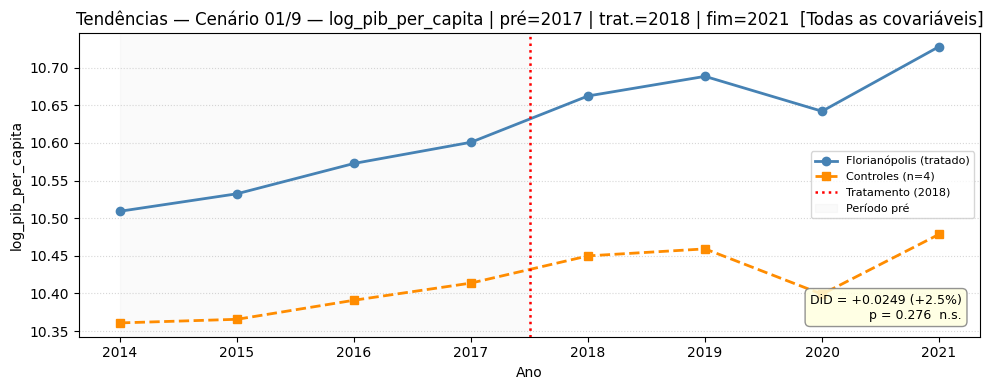

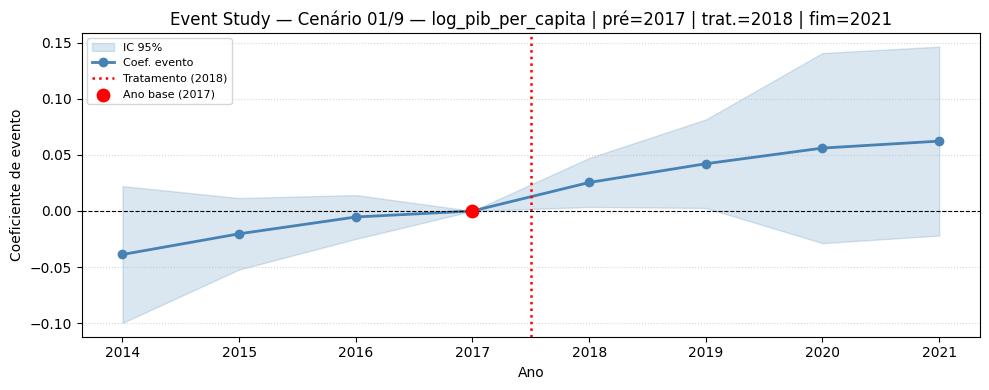


######################################################################
  Cenário 02/9 — log_pib_per_capita | pré=2017 | trat.=2018 | fim=2023
######################################################################

  Propensity scores:
    Florianópolis (tratado)             PS=0.0484
    -------------------------------------------------------
    Salvador                            PS=0.0449  dist=0.0035
    Rio de Janeiro                      PS=0.0447  dist=0.0037
    Recife                              PS=0.0415  dist=0.0068
    Belo Horizonte                      PS=0.0392  dist=0.0092

  ── Resultados por especificação ──


,Coef. DiD,EP,t,p,Sig.,Efeito (%),"IC 2,5%","IC 97,5%",R²,N obs.
Especificação,,,,,,,,,,
Sem covariáveis,0.038253,0.020432,1.8722,0.0696,*,3.90,-0.003227,0.079732,0.0543,50
Só log_populacao,0.090612,0.020860,4.3438,0.0001,***,9.48,0.048219,0.133005,0.2689,50
Só log_escolaridade,0.035879,0.018373,1.9528,0.0591,*,3.65,-0.001459,0.073217,0.0571,50
Só participações,0.001154,0.005208,0.2215,0.8267,n.s.,0.12,-0.009621,0.011928,0.7425,40
log_populacao + log_escolaridade,0.087335,0.016056,5.4392,0.0000,***,9.13,0.054668,0.120002,0.2927,50
Todas as covariáveis,0.024946,0.022304,1.1185,0.2760,n.s.,2.53,-0.021437,0.071330,0.7780,40


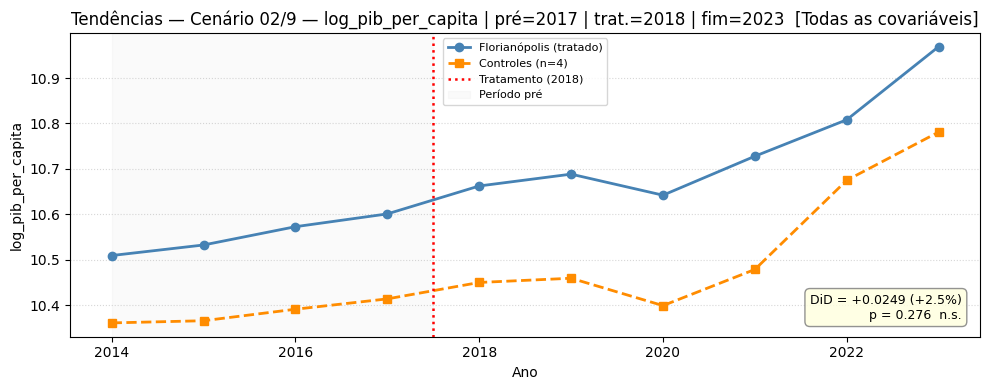

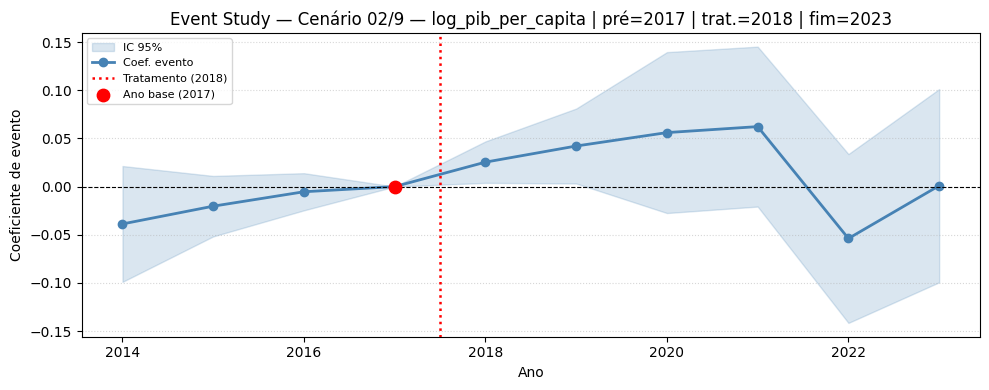


######################################################################
  Cenário 03/9 — log_pib_per_capita | pré=2018 | trat.=2019 | fim=2021
######################################################################

  Propensity scores:
    Florianópolis (tratado)             PS=0.0485
    -------------------------------------------------------
    Salvador                            PS=0.0464  dist=0.0021
    Rio de Janeiro                      PS=0.0429  dist=0.0056
    Recife                              PS=0.0390  dist=0.0095
    Belo Horizonte                      PS=0.0380  dist=0.0105

  ── Resultados por especificação ──


,Coef. DiD,EP,t,p,Sig.,Efeito (%),"IC 2,5%","IC 97,5%",R²,N obs.
Especificação,,,,,,,,,,
Sem covariáveis,0.061269,0.023019,2.6617,0.0129,**,6.32,0.014039,0.108500,0.1822,40
Só log_populacao,0.058799,0.034223,1.7181,0.0977,*,6.06,-0.011548,0.129146,0.1825,40
Só log_escolaridade,0.060412,0.020434,2.9564,0.0065,***,6.23,0.018409,0.102415,0.3071,40
Só participações,-0.005054,0.007331,-0.6894,0.4975,n.s.,-0.50,-0.020220,0.010111,0.7431,40
log_populacao + log_escolaridade,0.047391,0.031641,1.4978,0.1467,n.s.,4.85,-0.017774,0.112557,0.3164,40
Todas as covariáveis,0.016097,0.030904,0.5208,0.6079,n.s.,1.62,-0.048173,0.080366,0.7717,40


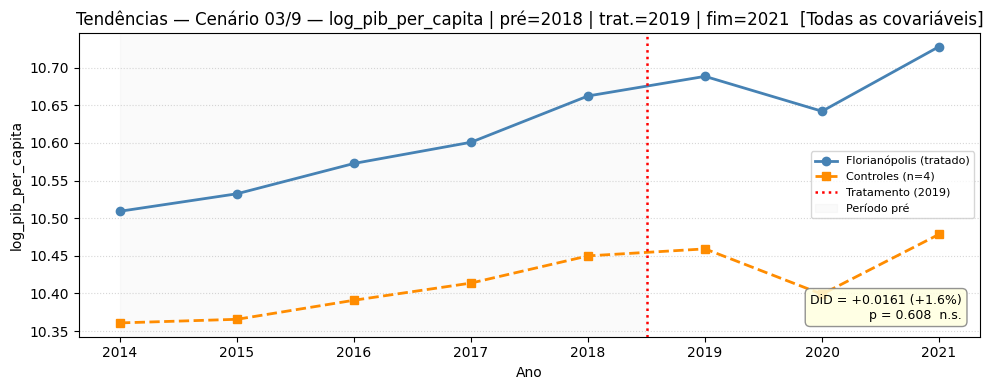

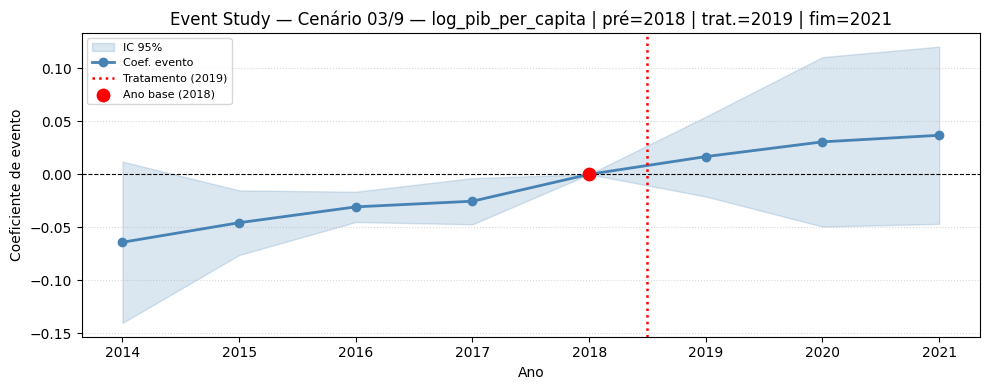


######################################################################
  Cenário 04/9 — log_pib_per_capita | pré=2018 | trat.=2019 | fim=2023
######################################################################

  Propensity scores:
    Florianópolis (tratado)             PS=0.0485
    -------------------------------------------------------
    Salvador                            PS=0.0464  dist=0.0021
    Rio de Janeiro                      PS=0.0429  dist=0.0056
    Recife                              PS=0.0390  dist=0.0095
    Belo Horizonte                      PS=0.0380  dist=0.0105

  ── Resultados por especificação ──


,Coef. DiD,EP,t,p,Sig.,Efeito (%),"IC 2,5%","IC 97,5%",R²,N obs.
Especificação,,,,,,,,,,
Sem covariáveis,0.029307,0.026286,1.1149,0.2725,n.s.,2.97,-0.024057,0.082671,0.0332,50
Só log_populacao,0.087552,0.033484,2.6147,0.0132,**,9.15,0.019504,0.155601,0.2453,50
Só log_escolaridade,0.026233,0.023669,1.1083,0.2755,n.s.,2.66,-0.021869,0.074334,0.0368,50
Só participações,-0.005054,0.007331,-0.6894,0.4975,n.s.,-0.50,-0.020220,0.010111,0.7431,40
log_populacao + log_escolaridade,0.083317,0.028498,2.9236,0.0062,***,8.69,0.025338,0.141296,0.2652,50
Todas as covariáveis,0.016097,0.030904,0.5208,0.6079,n.s.,1.62,-0.048173,0.080366,0.7717,40


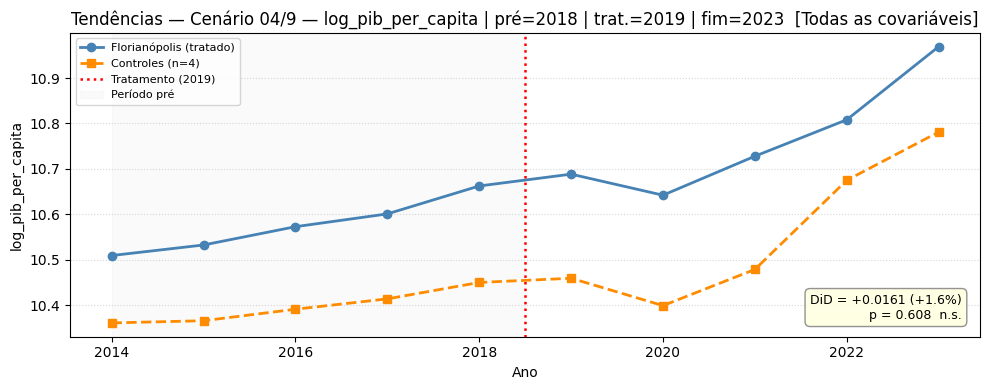

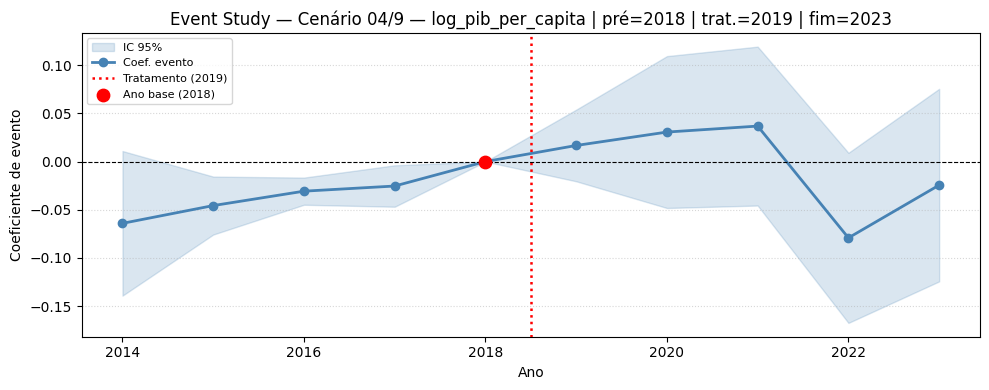


######################################################################
  Cenário 05/9 — log_pib_per_capita | pré=2019 | trat.=2020 | fim=2021
######################################################################

  Propensity scores:
    Florianópolis (tratado)             PS=0.0488
    -------------------------------------------------------
    Salvador                            PS=0.0474  dist=0.0014
    Rio de Janeiro                      PS=0.0409  dist=0.0079
    Recife                              PS=0.0406  dist=0.0082
    Belo Horizonte                      PS=0.0384  dist=0.0104

  ── Resultados por especificação ──


,Coef. DiD,EP,t,p,Sig.,Efeito (%),"IC 2,5%","IC 97,5%",R²,N obs.
Especificação,,,,,,,,,,
Sem covariáveis,0.058627,0.028371,2.0664,0.0485,**,6.04,0.000414,0.116840,0.1335,40
Só log_populacao,0.046112,0.040145,1.1486,0.2612,n.s.,4.72,-0.036407,0.128631,0.1450,40
Só log_escolaridade,0.061628,0.023375,2.6365,0.0139,**,6.36,0.013580,0.109676,0.2771,40
Só participações,-0.020990,0.016582,-1.2659,0.2182,n.s.,-2.08,-0.055292,0.013312,0.7466,40
log_populacao + log_escolaridade,0.042450,0.032524,1.3052,0.2037,n.s.,4.34,-0.024535,0.109435,0.3041,40
Todas as covariáveis,-0.000382,0.040123,-0.0095,0.9925,n.s.,-0.04,-0.083822,0.083058,0.7684,40


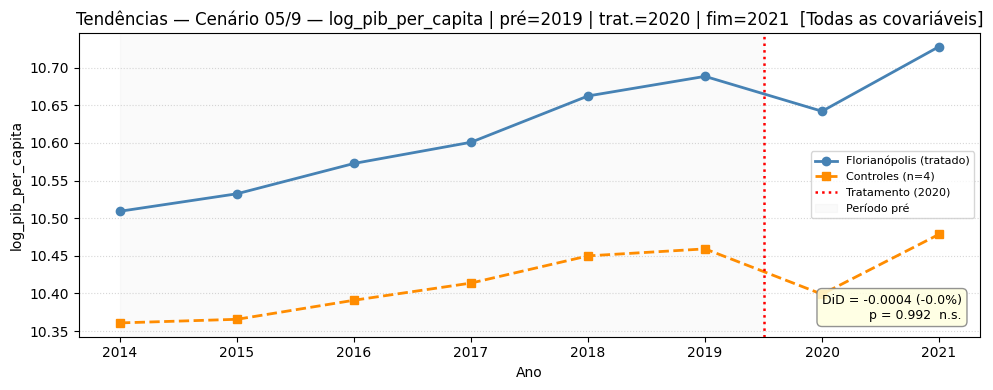

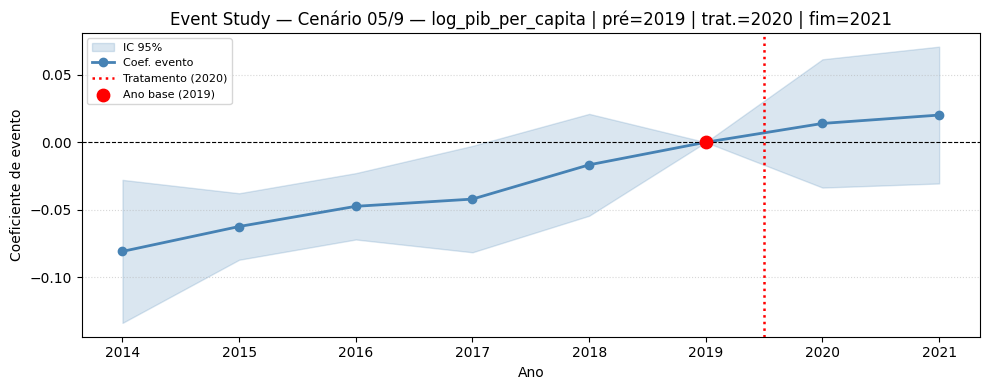


######################################################################
  Cenário 06/9 — log_pib_per_capita | pré=2019 | trat.=2020 | fim=2023
######################################################################

  Propensity scores:
    Florianópolis (tratado)             PS=0.0488
    -------------------------------------------------------
    Salvador                            PS=0.0474  dist=0.0014
    Rio de Janeiro                      PS=0.0409  dist=0.0079
    Recife                              PS=0.0406  dist=0.0082
    Belo Horizonte                      PS=0.0384  dist=0.0104

  ── Resultados por especificação ──


,Coef. DiD,EP,t,p,Sig.,Efeito (%),"IC 2,5%","IC 97,5%",R²,N obs.
Especificação,,,,,,,,,,
Sem covariáveis,0.015836,0.028599,0.5537,0.5833,n.s.,1.60,-0.042223,0.073895,0.0093,50
Só log_populacao,0.078591,0.043441,1.8091,0.0793,*,8.18,-0.009693,0.166875,0.1884,50
Só log_escolaridade,0.010796,0.025245,0.4276,0.6716,n.s.,1.09,-0.040509,0.062100,0.0165,50
Só participações,-0.020990,0.016582,-1.2659,0.2182,n.s.,-2.08,-0.055292,0.013312,0.7466,40
log_populacao + log_escolaridade,0.072863,0.037238,1.9567,0.0589,*,7.56,-0.002900,0.148625,0.2077,50
Todas as covariáveis,-0.000382,0.040123,-0.0095,0.9925,n.s.,-0.04,-0.083822,0.083058,0.7684,40


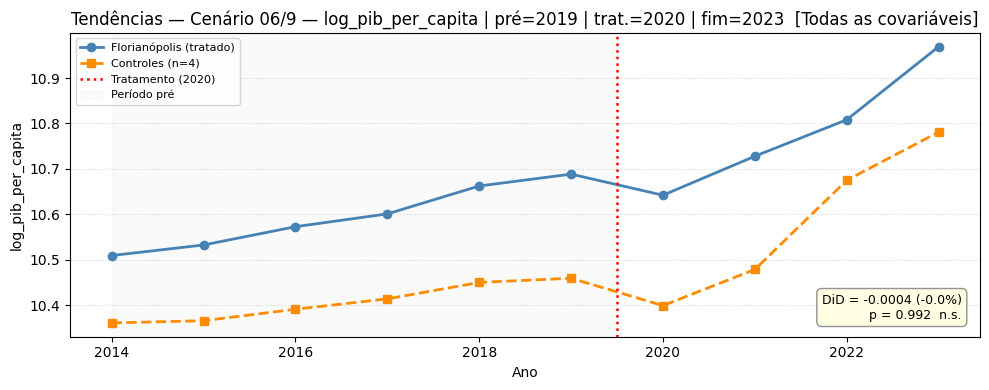

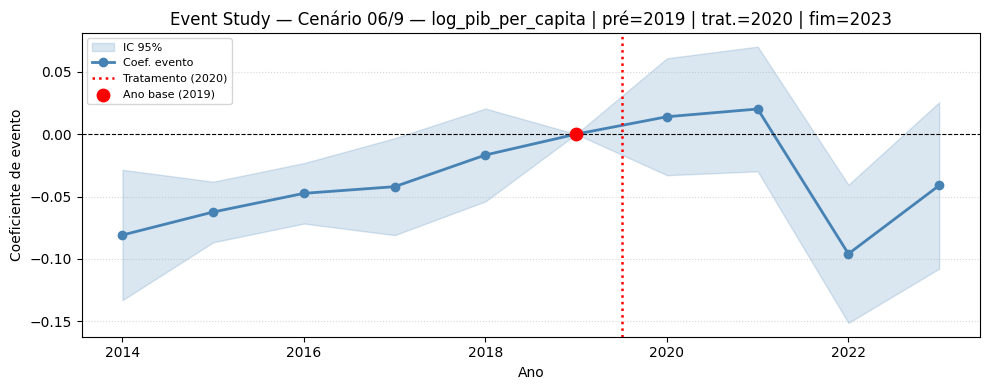


######################################################################
  Cenário 07/9 — log_pib_servicos_per_capita | pré=2017 | trat.=2018 | fim=2021
######################################################################

  Propensity scores:
    Florianópolis (tratado)             PS=0.0484
    -------------------------------------------------------
    Salvador                            PS=0.0449  dist=0.0035
    Rio de Janeiro                      PS=0.0447  dist=0.0037
    Recife                              PS=0.0415  dist=0.0068
    Belo Horizonte                      PS=0.0392  dist=0.0092

  ── Resultados por especificação ──


,Coef. DiD,EP,t,p,Sig.,Efeito (%),"IC 2,5%","IC 97,5%",R²,N obs.
Especificação,,,,,,,,,,
Sem covariáveis,0.084391,0.020653,4.0862,0.0004,***,8.81,0.042015,0.126766,0.2478,40
Só log_populacao,0.115468,0.028885,3.9975,0.0005,***,12.24,0.056094,0.174841,0.2792,40
Só log_escolaridade,0.081712,0.015220,5.3685,0.0000,***,8.51,0.050426,0.112998,0.3937,40
Só participações,-0.000985,0.005682,-0.1733,0.8639,n.s.,-0.10,-0.012739,0.010769,0.8248,40
log_populacao + log_escolaridade,0.096874,0.025793,3.7558,0.0009,***,10.17,0.043751,0.149996,0.4006,40
Todas as covariáveis,0.023378,0.022081,1.0588,0.3017,n.s.,2.37,-0.022541,0.069298,0.8497,40


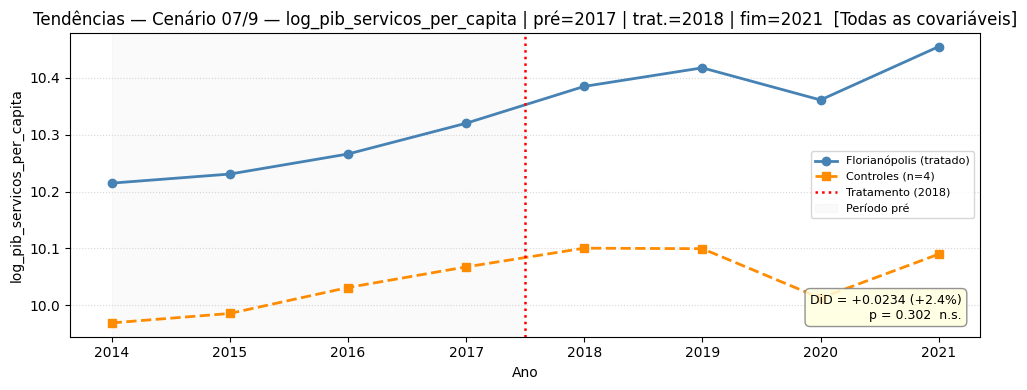

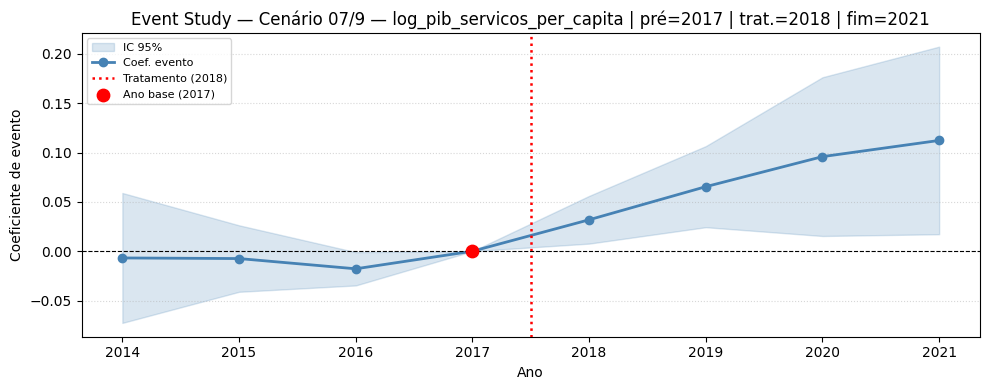


######################################################################
  Cenário 08/9 — log_pib_servicos_per_capita | pré=2018 | trat.=2019 | fim=2021
######################################################################

  Propensity scores:
    Florianópolis (tratado)             PS=0.0485
    -------------------------------------------------------
    Salvador                            PS=0.0464  dist=0.0021
    Rio de Janeiro                      PS=0.0429  dist=0.0056
    Recife                              PS=0.0390  dist=0.0095
    Belo Horizonte                      PS=0.0380  dist=0.0105

  ── Resultados por especificação ──


,Coef. DiD,EP,t,p,Sig.,Efeito (%),"IC 2,5%","IC 97,5%",R²,N obs.
Especificação,,,,,,,,,,
Sem covariáveis,0.091244,0.026541,3.4379,0.0019,***,9.55,0.036786,0.145701,0.2716,40
Só log_populacao,0.116366,0.038767,3.0017,0.0059,***,12.34,0.036679,0.196052,0.2964,40
Só log_escolaridade,0.090080,0.021465,4.1966,0.0003,***,9.43,0.045958,0.134202,0.4264,40
Só participações,-0.007431,0.007815,-0.9509,0.3515,n.s.,-0.74,-0.023598,0.008735,0.8257,40
log_populacao + log_escolaridade,0.102360,0.033337,3.0705,0.0051,***,10.78,0.033702,0.171019,0.4320,40
Todas as covariáveis,0.014594,0.030382,0.4803,0.6360,n.s.,1.47,-0.048590,0.077777,0.8459,40


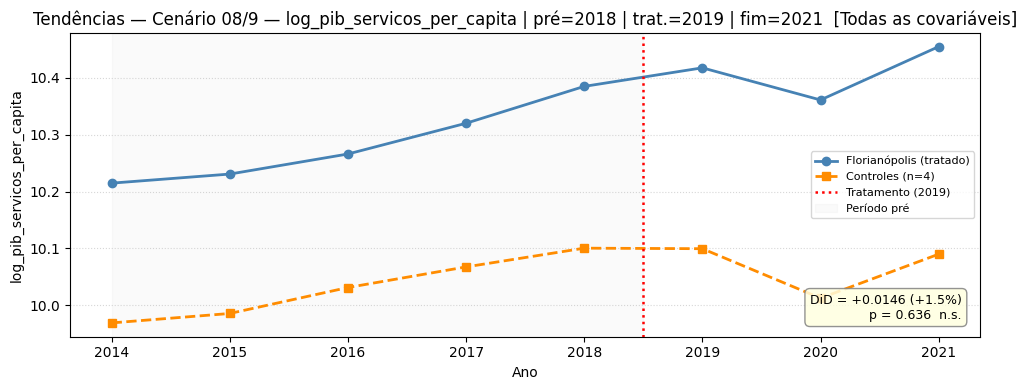

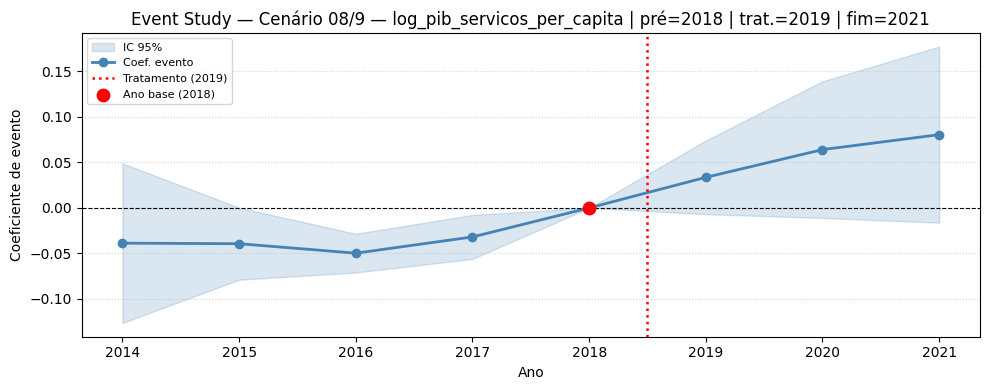


######################################################################
  Cenário 09/9 — log_pib_servicos_per_capita | pré=2019 | trat.=2020 | fim=2021
######################################################################

  Propensity scores:
    Florianópolis (tratado)             PS=0.0488
    -------------------------------------------------------
    Salvador                            PS=0.0474  dist=0.0014
    Rio de Janeiro                      PS=0.0409  dist=0.0079
    Recife                              PS=0.0406  dist=0.0082
    Belo Horizonte                      PS=0.0384  dist=0.0104

  ── Resultados por especificação ──


,Coef. DiD,EP,t,p,Sig.,Efeito (%),"IC 2,5%","IC 97,5%",R²,N obs.
Especificação,,,,,,,,,,
Sem covariáveis,0.093220,0.031222,2.9857,0.0060,***,9.77,0.029158,0.157283,0.2268,40
Só log_populacao,0.101124,0.048518,2.0843,0.0471,**,10.64,0.001394,0.200854,0.2299,40
Só log_escolaridade,0.097336,0.024002,4.0553,0.0004,***,10.22,0.047999,0.146673,0.4084,40
Só participações,-0.024344,0.017469,-1.3935,0.1768,n.s.,-2.40,-0.060481,0.011794,0.8285,40
log_populacao + log_escolaridade,0.096392,0.038341,2.5141,0.0187,**,10.12,0.017427,0.175357,0.4085,40
Todas as covariáveis,-0.002062,0.039715,-0.0519,0.9591,n.s.,-0.21,-0.084653,0.080530,0.8441,40


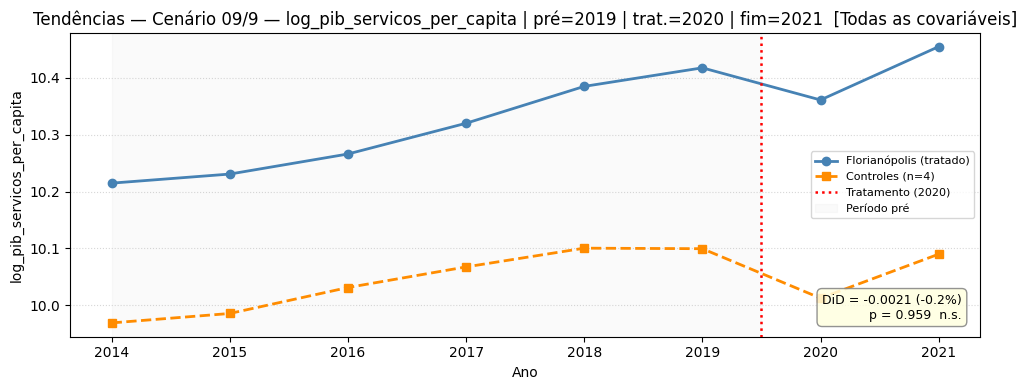

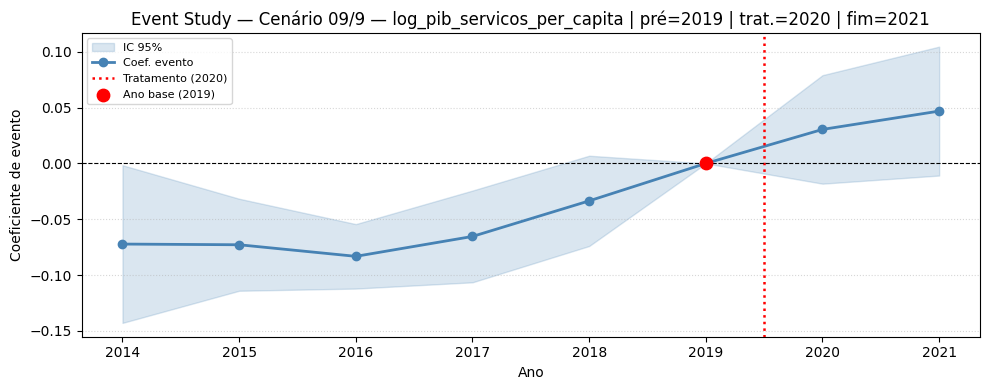


✅ Concluído — 54 modelos (9 cenários × 6 especificações)


In [66]:
resultados = []
total = len(CENARIOS)

for cenario, (var_dep, ano_pre, ano_fim) in enumerate(CENARIOS, start=1):

    ano_tratamento = ano_pre + 1
    rotulo = (
        f"Cenário {cenario:02d}/{total} — {var_dep} "
        f"| pré={ano_pre} | trat.={ano_tratamento} | fim={ano_fim}"
    )

    # ── Cabeçalho do cenário ──────────────────────────────────
    print(f"\n{'#'*70}")
    print(f"  {rotulo}")
    print(f"{'#'*70}")

    # ── 1–4: Matching ─────────────────────────────────────────
    df_m   = preparar_base(df_combinado, df_distancia_filtrado, MUNICIPIO_TRATADO, ano_pre)
    df_avg = construir_covariaveis(df_m, ANO_MATCHING_INICIO, ano_pre, MUNICIPIO_TRATADO)
    df_avg = estimar_propensity_score(df_avg, COVARIAVEIS_MATCHING)
    _, grupo_controle = realizar_matching(df_avg, MUNICIPIO_TRATADO, K_CONTROLES, CALIPER)

    ps_flp = df_avg.loc[df_avg["id_municipio"] == MUNICIPIO_TRATADO, "propensity_score"].iloc[0]
    print("\n  Propensity scores:")
    print(f"    {'Florianópolis (tratado)':<35} PS={ps_flp:.4f}")
    print(f"    {'-'*55}")
    for _, r in grupo_controle[["municipio", "propensity_score", "distancia_ps"]].iterrows():
        print(f"    {r['municipio']:<35} PS={r['propensity_score']:.4f}  dist={r['distancia_ps']:.4f}")

    # ── 5: Amostra DiD ────────────────────────────────────────
    df_did, _ = construir_amostra_did(
        df_m, MUNICIPIO_TRATADO, grupo_controle,
        ano_pre, ANO_MATCHING_INICIO, ano_fim
    )

    if var_dep not in df_did.columns:
        print(f"  ⚠️  {var_dep} ausente no painel — cenário ignorado")
        continue

    # ── 6: Loop de especificações DiD ─────────────────────────
    res_por_spec  = {}   # rótulo → objeto resultado (para os gráficos)

    for rotulo_spec, covs in ESPECIFICACOES_DID:
        try:
            res, _ = estimar_did(df_did, var_dep, covs)
            res_por_spec[rotulo_spec] = res
            resultados.append(consolidar_resultado(
                var_dep, ano_pre, ano_fim, rotulo_spec, grupo_controle, res
            ))
        except Exception as e:
            print(f"  ⚠️  [{rotulo_spec}] Erro: {e}")

    # ── Tabela comparativa das especificações deste cenário ───
    linhas_cen = [
        r for r in resultados
        if r["var_dep"] == var_dep
        and r["ano_pre"] == ano_pre
        and r["ano_fim"] == ano_fim
    ]
    if linhas_cen:
        print("\n  ── Resultados por especificação ──")
        display(
            pd.DataFrame(linhas_cen)
            .rename(columns={
                "covariáveis" : "Especificação",
                "coef_did"    : "Coef. DiD",
                "erro_padrao" : "EP",
                "t_stat"      : "t",
                "p_valor"     : "p",
                "efeito_pct"  : "Efeito (%)",
                "r2_within"   : "R²",
                "sig"         : "Sig.",
                "n_obs"       : "N obs.",
                "ic_25"       : "IC 2,5%",
                "ic_975"      : "IC 97,5%",
            })
            [["Especificação", "Coef. DiD", "EP", "t", "p", "Sig.",
              "Efeito (%)", "IC 2,5%", "IC 97,5%", "R²", "N obs."]]
            .set_index("Especificação")
        )

    # ── Gráficos: usa modelo completo (última especificação bem-sucedida) ──
    rotulo_graf = [r for r, _ in ESPECIFICACOES_DID if r in res_por_spec]
    if rotulo_graf:
        res_graf  = res_por_spec[rotulo_graf[-1]]
        coef_g    = float(res_graf.params["did"])
        pval_g    = float(res_graf.pvalues["did"])
        plot_tendencias(
            df_did, var_dep, ano_tratamento, len(grupo_controle),
            coef_g, pval_g,
            f"Tendências — {rotulo}  [{rotulo_graf[-1]}]"
        )
        plot_event_study(
            df_did, var_dep, ano_tratamento,
            f"Event Study — {rotulo}"
        )

print(f"\n✅ Concluído — {len(resultados)} modelos ({total} cenários × {len(ESPECIFICACOES_DID)} especificações)")

### Tabela consolidada de resultados

Comparação direta entre todas as especificações estimadas.

In [67]:
df_resultados = (
    pd.DataFrame(resultados)
    .rename(columns={
        "var_dep"      : "Var. dependente",
        "ano_pre"      : "Ano pré",
        "ano_fim"      : "Ano fim",
        "covariáveis"  : "Covariáveis",
        "n_controles"  : "N contr.",
        "n_obs"        : "N obs.",
        "coef_did"     : "Coef. DiD",
        "erro_padrao"  : "EP",
        "t_stat"       : "t",
        "p_valor"      : "p-valor",
        "ic_25"        : "IC 2,5%",
        "ic_975"       : "IC 97,5%",
        "efeito_pct"   : "Efeito (%)",
        "r2_within"    : "R² within",
        "sig"          : "Sig.",
    })
)

print("Nota: TWFE com EF município + ano. Erros clusterizados por município.")
print("      * p<0.10  ** p<0.05  *** p<0.01\n")
df_resultados

Nota: TWFE com EF município + ano. Erros clusterizados por município.
      * p<0.10  ** p<0.05  *** p<0.01



,Var. dependente,Ano pré,Ano fim,Covariáveis,N contr.,N obs.,Coef. DiD,EP,t,p-valor,"IC 2,5%","IC 97,5%",Efeito (%),R² within,Sig.
0,log_pib_per_capita,2017,2021,Sem covariáveis,4,40,0.062548,0.015847,3.9471,0.0005,0.030033,0.095063,6.45,0.2025,***
1,log_pib_per_capita,2017,2021,Só log_populacao,4,40,0.067118,0.022556,2.9757,0.0062,0.020754,0.113482,6.94,0.2035,***
2,log_pib_per_capita,2017,2021,Só log_escolaridade,4,40,0.060580,0.013157,4.6043,0.0001,0.033535,0.087626,6.25,0.3197,***
3,log_pib_per_capita,2017,2021,Só participações,4,40,0.001154,0.005208,0.2215,0.8267,-0.009621,0.011928,0.12,0.7425,n.s.
4,log_pib_per_capita,2017,2021,log_populacao + log_escolaridade,4,40,0.051998,0.021311,2.4400,0.0221,0.008108,0.095889,5.34,0.3229,**
5,log_pib_per_capita,2017,2021,Todas as covariáveis,4,40,0.024946,0.022304,1.1185,0.2760,-0.021437,0.071330,2.53,0.7780,n.s.
6,log_pib_per_capita,2017,2023,Sem covariáveis,4,50,0.038253,0.020432,1.8722,0.0696,-0.003227,0.079732,3.90,0.0543,*
7,log_pib_per_capita,2017,2023,Só log_populacao,4,50,0.090612,0.020860,4.3438,0.0001,0.048219,0.133005,9.48,0.2689,***
8,log_pib_per_capita,2017,2023,Só log_escolaridade,4,50,0.035879,0.018373,1.9528,0.0591,-0.001459,0.073217,3.65,0.0571,*
9,log_pib_per_capita,2017,2023,Só participações,4,40,0.001154,0.005208,0.2215,0.8267,-0.009621,0.011928,0.12,0.7425,n.s.


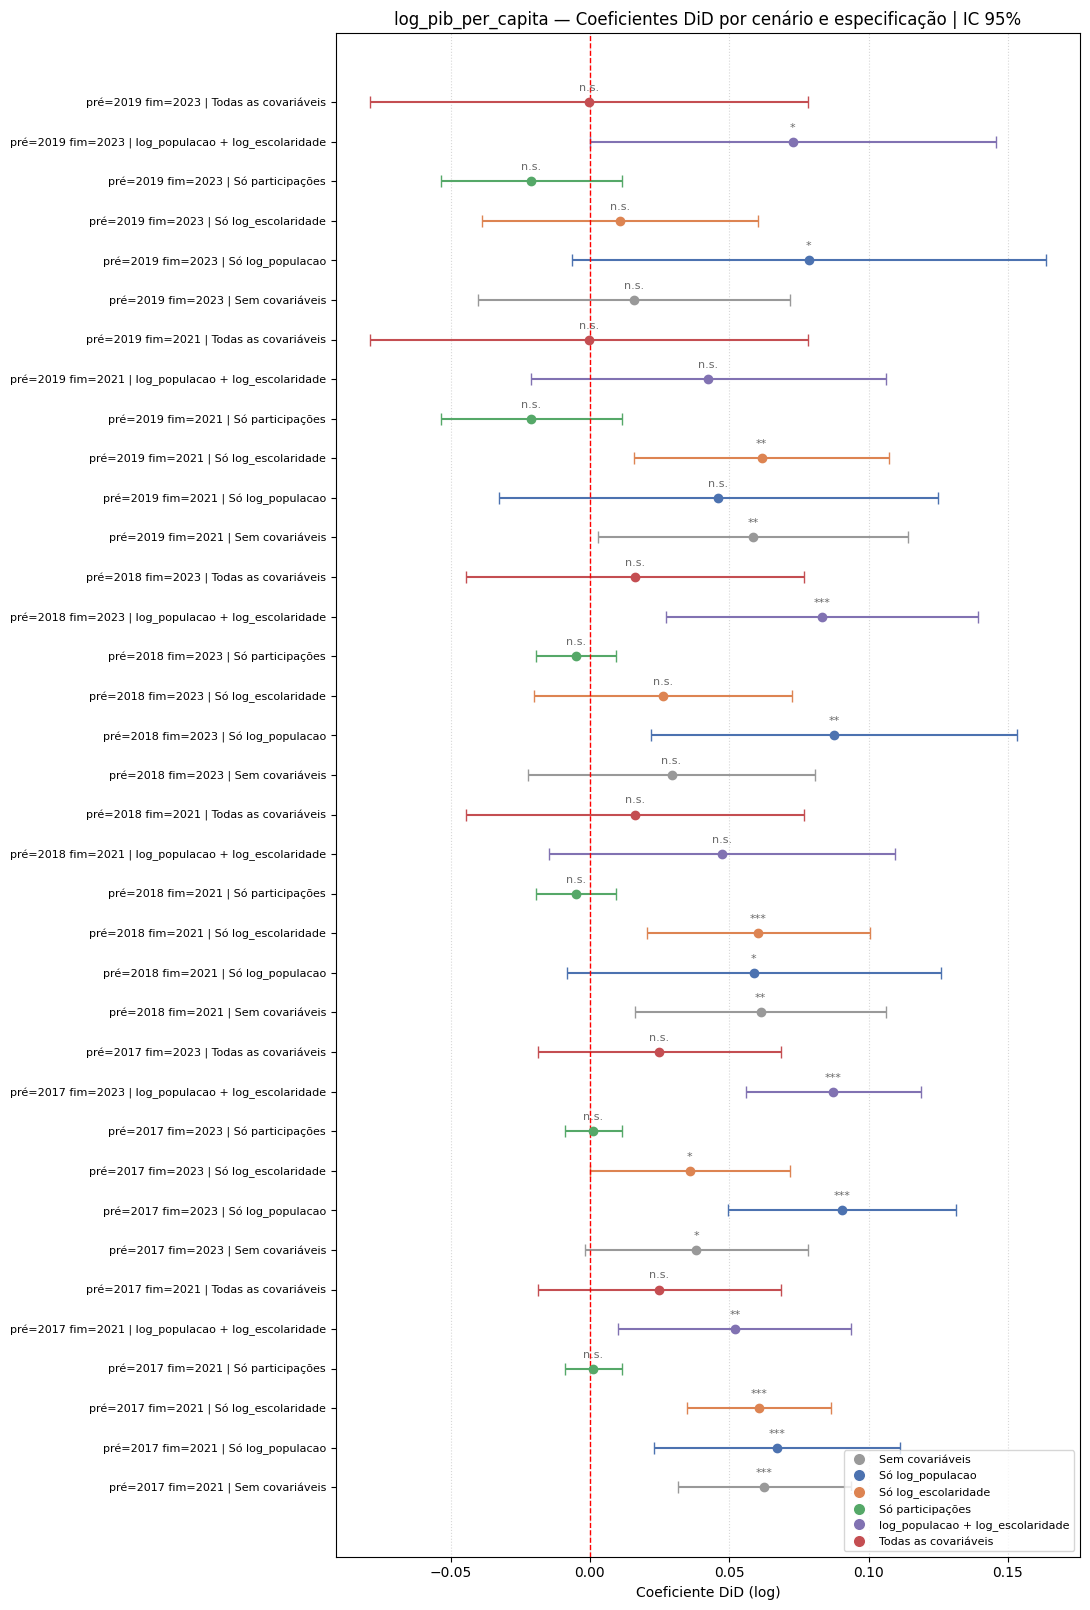

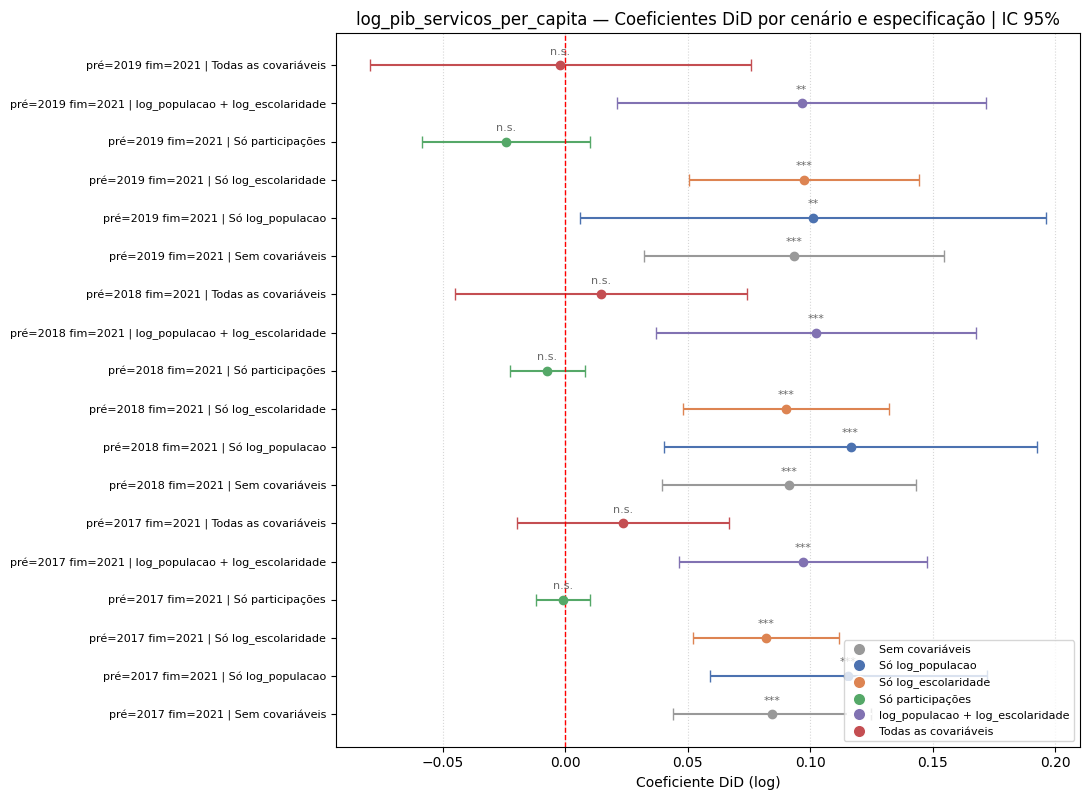

In [68]:
paleta = {
    "Sem covariáveis"                  : "#999999",
    "Só log_populacao"                 : "#4C72B0",
    "Só log_escolaridade"              : "#DD8452",
    "Só participações"                 : "#55A868",
    "log_populacao + log_escolaridade" : "#8172B2",
    "Todas as covariáveis"             : "#C44E52",
}

for var in ["log_pib_per_capita", "log_pib_servicos_per_capita"]:
    sub = df_resultados[df_resultados["Var. dependente"] == var].copy().reset_index(drop=True)
    if sub.empty:
        continue

    sub["eixo_y"] = (
        "pré=" + sub["Ano pré"].astype(str)
        + " fim=" + sub["Ano fim"].astype(str)
        + " | " + sub["Covariáveis"]
    )

    fig, ax = plt.subplots(figsize=(11, max(5, len(sub) * 0.45)))

    for i, row in sub.iterrows():
        cor = paleta.get(row["Covariáveis"], "steelblue")
        ax.errorbar(
            row["Coef. DiD"], i,
            xerr=1.96 * row["EP"],
            fmt="o", color=cor, capsize=4, lw=1.5
        )
        ax.text(
            row["Coef. DiD"], i + 0.28,
            row["Sig."], ha="center", fontsize=8, color="dimgray"
        )

    ax.axvline(0, color="red", ls="--", lw=1)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub["eixo_y"], fontsize=8)
    ax.set_xlabel("Coeficiente DiD (log)")
    ax.set_title(f"{var} — Coeficientes DiD por cenário e especificação | IC 95%")
    ax.grid(axis="x", ls=":", alpha=0.5)

    from matplotlib.lines import Line2D
    handles = [Line2D([0],[0], marker="o", color="w", markerfacecolor=c,
                      markersize=9, label=l)
               for l, c in paleta.items()]
    ax.legend(handles=handles, fontsize=8, loc="lower right")

    plt.tight_layout()
    plt.show()